In [387]:
# Imports for the interval propagation and physical bank control notebook

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import constants
import AtmosphereModel
import control
import ReactionControl

from interval_math import Interval, promote
from math_3d import (
    IntervalSupervisorConfig,
    annotate_nominal_state_with_interval_supervisor,
    f_interval,
    nominal_state_to_interval_box,
)

from control import (
    ReentryState,
    GuidanceScheduler,
    SimpleBankGuidance,
    BasicObservationProvider,
    BankActuatorLimits,
    BankActuator,
    RollTorqueController,
    CapsuleControlConfig,
    CapsuleControlStack,
    wrap_to_pi,
)

from ReactionControl import (
    build_orion_cm_rcs_12,
)

## helper functions for plotting the interval stuff

In [388]:
# Helper functions for readable logging, plotting, and milestone 1 roll updates

STATE_NAMES = ["r_m", "phi_rad", "lam_rad", "V_mps", "gamma_rad", "chi_rad"]


def interval_mid(iv):
    return 0.5 * (iv.lo + iv.hi)


def interval_width(iv):
    return iv.hi - iv.lo


def box_mid(box):
    return [interval_mid(iv) for iv in box]


def box_widths(box):
    return [interval_width(iv) for iv in box]


def deg(x_rad):
    return math.degrees(x_rad)


def alt_from_r(r_m):
    return r_m - constants.RADIUS_EARTH


def wrap_angle_rad(x_rad):
    return wrap_to_pi(float(x_rad))


def atmosphere_from_state_vector(x):
    r_m, _, _, V_mps, _, _ = x
    alt_m = max(0.0, alt_from_r(r_m))
    atm = AtmosphereModel.US_Standard_ATM(alt_m)

    rho = atm["rho_kgm3"] if atm["rho_kgm3"] is not None else 0.0
    T_K = atm["T_K"] if atm["T_K"] is not None else np.nan
    p_Pa = atm["p_Pa"] if atm["p_Pa"] is not None else np.nan
    q_pa = 0.5 * rho * V_mps * V_mps

    return {
        "alt_m": alt_m,
        "rho_kgm3": rho,
        "T_K": T_K,
        "p_Pa": p_Pa,
        "q_pa": q_pa,
    }


def nominal_aero_forces_from_state(x, sigma_rad, params):
    r_m, phi_rad, lam_rad, V_mps, gamma_rad, chi_rad = x
    del phi_rad, lam_rad

    atm = atmosphere_from_state_vector(x)
    rho = atm["rho_kgm3"]
    q_pa = atm["q_pa"]

    S = float(params["ref_area_m2"])
    CD = float(params["CD_const"])
    CL = float(params["CL_const"])

    drag_mag_N = q_pa * S * CD
    lift_mag_N = q_pa * S * CL

    sin_gamma = math.sin(gamma_rad)
    cos_gamma = math.cos(gamma_rad)
    sin_chi = math.sin(chi_rad)
    cos_chi = math.cos(chi_rad)
    sin_sigma = math.sin(sigma_rad)
    cos_sigma = math.cos(sigma_rad)

    v_r = sin_gamma
    v_theta = cos_gamma * cos_chi
    v_phi = cos_gamma * sin_chi

    D_r = -drag_mag_N * v_r
    D_theta = drag_mag_N * v_theta
    D_phi = -drag_mag_N * v_phi

    e1_r = cos_gamma
    e1_theta = -sin_gamma * cos_chi
    e1_phi = -sin_gamma * sin_chi

    e2_r = 0.0
    e2_theta = sin_chi
    e2_phi = -cos_chi

    L_r = lift_mag_N * (e1_r * cos_sigma + e2_r * sin_sigma)
    L_theta = lift_mag_N * (e1_theta * cos_sigma + e2_theta * sin_sigma)
    L_phi = lift_mag_N * (e1_phi * cos_sigma + e2_phi * sin_sigma)

    return {
        "rho_kgm3": rho,
        "q_pa": q_pa,
        "drag_mag_N": drag_mag_N,
        "lift_mag_N": lift_mag_N,
        "D_r_N": D_r,
        "D_theta_N": D_theta,
        "D_phi_N": D_phi,
        "L_r_N": L_r,
        "L_theta_N": L_theta,
        "L_phi_N": L_phi,
    }


def nominal_eom_step(x, sigma_rad, params, dt_s):
    r_m, phi_rad, lam_rad, V_mps, gamma_rad, chi_rad = x

    aero = nominal_aero_forces_from_state(x, sigma_rad, params)

    m = float(params["mass_kg"])
    g = constants.gravity(r_m)

    cos_phi = math.cos(phi_rad)
    sin_phi = math.sin(phi_rad)
    cos_gamma = math.cos(gamma_rad)
    sin_gamma = math.sin(gamma_rad)
    sin_chi = math.sin(chi_rad)
    cos_chi = math.cos(chi_rad)

    eps = 1.0e-9
    safe_r = max(r_m, constants.RADIUS_EARTH + 1.0)
    safe_V = max(abs(V_mps), eps)

    if abs(cos_phi) < eps:
        cos_phi = eps if cos_phi >= 0.0 else -eps

    if abs(cos_gamma) < eps:
        cos_gamma = eps if cos_gamma >= 0.0 else -eps

    r_dot = V_mps * sin_gamma
    phi_dot = (V_mps * cos_gamma * sin_chi) / safe_r
    lam_dot = (V_mps * cos_gamma * cos_chi) / (safe_r * cos_phi)

    V_dot = (aero["D_r_N"] + aero["L_r_N"]) / m - g * sin_gamma
    gamma_dot = (aero["L_theta_N"] / (m * safe_V)) + (safe_V / safe_r - g / safe_V) * cos_gamma
    chi_dot = (aero["L_phi_N"] / (m * safe_V * cos_gamma)) + (safe_V / safe_r) * sin_chi * (sin_phi / cos_phi)

    x_next = [
        r_m + r_dot * dt_s,
        phi_rad + phi_dot * dt_s,
        lam_rad + lam_dot * dt_s,
        V_mps + V_dot * dt_s,
        gamma_rad + gamma_dot * dt_s,
        chi_rad + chi_dot * dt_s,
    ]

    return {
        "x_next": x_next,
        "x_dot": [r_dot, phi_dot, lam_dot, V_dot, gamma_dot, chi_dot],
        "aero": aero,
        "gravity_mps2": g,
    }


def milestone1_roll_update(
    sigma_actual_rad,
    roll_rate_rad_s,
    tau_rcs_z_Nm,
    dt_s,
    Izz_kgm2,
):
    roll_accel_rad_s2 = float(tau_rcs_z_Nm) / float(Izz_kgm2)
    roll_rate_next_rad_s = float(roll_rate_rad_s) + roll_accel_rad_s2 * float(dt_s)
    sigma_actual_next_rad = wrap_angle_rad(
        float(sigma_actual_rad) + roll_rate_next_rad_s * float(dt_s)
    )

    return {
        "roll_accel_rad_s2": roll_accel_rad_s2,
        "roll_rate_next_rad_s": roll_rate_next_rad_s,
        "sigma_actual_next_rad": sigma_actual_next_rad,
    }

In [ ]:
# Vehicle aerodynamic control and reaction control system setup used by the notebook

# Define the physical and aerodynamic properties of the capsule
params = {
    "mass_kg": float(constants.CAPSULE_MASS_KG),
    "ref_area_m2": float(constants.CAPSULE_REFERENCE_AREA_M2),
    "CD_const": 1.05,
    "CL_const": 0.32,
}

# Define the simulation time step and total duration
dt_s = float(constants.ENTRY_DT_S)
t_final_s = 240.0
num_steps = int(t_final_s / dt_s)

# Define the moment of inertia for the roll axis
Izz_kgm2 = float(constants.CAPSULE_IZZ_KGM2)

# Define the landing target latitude and longitude in radians
target_phi_rad = math.radians(63.152)
target_lam_rad = math.radians(55.96)

# Configure the guidance loop and scheduler
control_cfg = CapsuleControlConfig(
    guidance_period_s=float(constants.GUIDANCE_PERIOD_S),
)

guidance_scheduler = GuidanceScheduler(
    period_s=float(constants.GUIDANCE_PERIOD_S),
)

# Setup the bank angle guidance logic with upper and lower limits
guidance_law = SimpleBankGuidance(
    max_bank_deg=70.0,
    min_bank_deg=40.0,
    downrange_gain=1e-6,
    velocity_enable_mps=20000.0,
)

# Provide the observation model with the landing targets and capsule parameters
observation_provider = BasicObservationProvider(
    target_phi_rad=target_phi_rad,
    target_lam_rad=target_lam_rad,
    params=params,
)

# Define the physical limits for the bank actuator
bank_actuator = BankActuator(
    BankActuatorLimits(
        sigma_rate_max_rps=math.radians(20.0),
        sigma_accel_max_rps2=math.radians(40.0),
    )
)

# Tune the proportional derivative roll torque controller
roll_controller = RollTorqueController(
    kp_Nm_per_rad=float(constants.ROLL_KP_NM_PER_RAD),
    kd_Nm_per_rad_s=float(constants.ROLL_KD_NM_PER_RAD_S),
    max_torque_Nm=float(constants.ROLL_CMD_MAX_TORQUE_NM),
    sigma_deadband_rad=float(constants.ROLL_SIGMA_DEADBAND_RAD),
    rate_deadband_rad_s=float(constants.ROLL_RATE_DEADBAND_RAD_S),
)

# Assemble the full capsule control stack combining guidance and physical controllers
capsule_control = CapsuleControlStack(
    cfg=control_cfg,
    scheduler=guidance_scheduler,
    guidance=guidance_law,
    obs_provider=observation_provider,
    bank_actuator=bank_actuator,
    roll_controller=roll_controller,
)

# Initialize the reaction control system for the capsule
rcs_system = build_orion_cm_rcs_12()

# Configure the interval supervisor with uncertainty widths for state variables
supervisor_cfg = IntervalSupervisorConfig(
    r_half_width_m=25.0,
    phi_half_width_rad=math.radians(0.005),
    lam_half_width_rad=math.radians(0.005),
    V_half_width_mps=5.0,
    gamma_half_width_rad=math.radians(0.05),
    chi_half_width_rad=math.radians(0.05),
    min_altitude_m=0.0,
    max_dynamic_pressure_pa=120000.0,
    include_heating=True,
)

# Reset the control stack and reaction control system to their initial states
capsule_control.reset()
rcs_system.reset()

# Output a summary dictionary of the configuration
{
    "params": params,
    "dt_s": dt_s,
    "t_final_s": t_final_s,
    "num_steps": num_steps,
    "Izz_kgm2": Izz_kgm2,
    "guidance_period_s": constants.GUIDANCE_PERIOD_S,
    "roll_pos_thrusters": rcs_system.roll_pos_names,
    "roll_neg_thrusters": rcs_system.roll_neg_names,
}

{'params': {'mass_kg': 8500.0,
  'ref_area_m2': 19.634954084936208,
  'CD_const': 1.05,
  'CL_const': 0.32},
 'dt_s': 0.25,
 't_final_s': 240.0,
 'num_steps': 960,
 'Izz_kgm2': 20000.0,
 'guidance_period_s': 1.0,
 'roll_pos_thrusters': ['POD0_RPOS', 'POD1_RPOS', 'POD2_RPOS', 'POD3_RPOS'],
 'roll_neg_thrusters': ['POD0_RNEG', 'POD1_RNEG', 'POD2_RNEG', 'POD3_RNEG']}

In [390]:
# Initial nominal translational and roll state

# State order
# r
# phi
# lam
# V
# gamma
# chi

# Define the starting conditions for the spacecraft trajectory
x_nominal = [
    constants.RADIUS_EARTH + 80_000.0,
    math.radians(0.0),
    math.radians(0.0),
    7_500.0,
    math.radians(-5.5),
    math.radians(90.0),
]

# Initialize the starting bank angle and roll rate to zero
sigma_actual_0_rad = 0.0
roll_rate_0_rad_s = 0.0

# Create the control state object using the established initial conditions
state_ctrl = ReentryState(
    r_m=float(x_nominal[0]),
    phi_rad=float(x_nominal[1]),
    lam_rad=float(x_nominal[2]),
    V_mps=float(x_nominal[3]),
    gamma_rad=float(x_nominal[4]),
    chi_rad=float(x_nominal[5]),
    sigma_actual_rad=float(sigma_actual_0_rad),
    roll_rate_rad_s=float(roll_rate_0_rad_s),
    sigma_cmd_rad=0.0,
    sigma_target_rad=0.0,
)

# Clear any previous states in the control and reaction control systems
capsule_control.reset()
rcs_system.reset()

# Output the starting conditions for verification
print("Initial altitude m", alt_from_r(x_nominal[0]))
print("Initial speed m per s", x_nominal[3])
print("Initial gamma deg", deg(x_nominal[4]))
print("Initial chi deg", deg(x_nominal[5]))
print("Initial sigma_actual deg", deg(state_ctrl.sigma_actual_rad))
print("Initial roll_rate deg per s", deg(state_ctrl.roll_rate_rad_s))

Initial altitude m 80000.0
Initial speed m per s 7500.0
Initial gamma deg -5.5
Initial chi deg 90.0
Initial sigma_actual deg 0.0
Initial roll_rate deg per s 0.0


In [ ]:
# Interval supervisor settings

# These widths define translational state uncertainty only.
# The bank angle used by the nominal path remains deterministic.
# The interval layer annotates uncertainty around that flown nominal motion.

supervisor_cfg = IntervalSupervisorConfig(
    r_half_width_m=10.0,
    phi_half_width_rad=math.radians(0.01),
    lam_half_width_rad=math.radians(0.01),
    V_half_width_mps=20.0,
    gamma_half_width_rad=math.radians(0.15),
    chi_half_width_rad=math.radians(0.20),
    min_altitude_m=0.0,
    max_altitude_m=130_000.0,
    max_speed_mps=80_000.0,
    max_dynamic_pressure_pa=5.0e7,
    include_heating=True,
)

x_interval = nominal_state_to_interval_box(x_nominal)

supervisor_cfg

IntervalSupervisorConfig(r_half_width_m=150.0, phi_half_width_rad=0.00017453292519943296, lam_half_width_rad=0.00017453292519943296, V_half_width_mps=20.0, gamma_half_width_rad=0.002617993877991494, chi_half_width_rad=0.003490658503988659, min_altitude_m=0.0, max_altitude_m=130000.0, max_speed_mps=80000.0, max_dynamic_pressure_pa=50000000.0, include_heating=True)

## Deterministic bank schedule

In [392]:
# Setup objects for the physical closed loop bank control path

# This notebook no longer uses a hand written sigma schedule.
# The nominal path now follows:
# guidance -> sigma_cmd
# actuator -> sigma_target
# roll controller -> tau_roll_cmd_Nm
# RCS -> body torque
# roll dynamics -> sigma_actual
# translational step uses sigma_actual

capsule_control.reset()
rcs_system.reset()

interval_heat_shield = None

log_columns = [
    "step",
    "t_s",
    "guidance_updated",
    "sigma_cmd_rad",
    "sigma_target_rad",
    "sigma_actual_rad",
    "roll_rate_rad_s",
    "roll_accel_rad_s2",
    "tau_roll_cmd_Nm",
    "tau_roll_capacity_Nm",
    "requested_duty",
    "fired_this_step",
    "active_thrusters",
    "torque_z_from_rcs",
    "force_x_from_rcs",
    "force_y_from_rcs",
    "force_z_from_rcs",
    "r_m",
    "phi_rad",
    "lam_rad",
    "V_mps",
    "gamma_rad",
    "chi_rad",
    "alt_m",
    "rho_kgm3",
    "q_pa",
    "T_K",
    "p_Pa",
    "drag_mag_N",
    "lift_mag_N",
    "gravity_mps2",
    "interval_sigma_lo",
    "interval_sigma_hi",
    "interval_rho_lo",
    "interval_rho_hi",
    "interval_q_lo",
    "interval_q_hi",
    "interval_alt_lo",
    "interval_alt_hi",
    "width_r_m",
    "width_phi_rad",
    "width_lam_rad",
    "width_V_mps",
    "width_gamma_rad",
    "width_chi_rad",
    "dx_width_r",
    "dx_width_phi",
    "dx_width_lam",
    "dx_width_V",
    "dx_width_gamma",
    "dx_width_chi",
    "heating_qdot_max_lo",
    "heating_qdot_max_hi",
    "heating_qdot_mean_lo",
    "heating_qdot_mean_hi",
    "heating_Q_max_lo",
    "heating_Q_max_hi",
    "safety_status",
    "safety_checks",
    "layer_indices",
]

print("Closed loop setup ready")
print("Guidance period s", float(constants.GUIDANCE_PERIOD_S))
print("Physics dt s", dt_s)
print("Positive roll thrusters", rcs_system.roll_pos_names)
print("Negative roll thrusters", rcs_system.roll_neg_names)

Closed loop setup ready
Guidance period s 1.0
Physics dt s 0.25
Positive roll thrusters ['POD0_RPOS', 'POD1_RPOS', 'POD2_RPOS', 'POD3_RPOS']
Negative roll thrusters ['POD0_RNEG', 'POD1_RNEG', 'POD2_RNEG', 'POD3_RNEG']


## Nominal translational step using the same interval equations

In [393]:
# Nominal translational step driven by the physically flown sigma_actual

# The nominal translational dynamics are stepped with the actual bank angle
# produced by the control stack, RCS allocation, and milestone 1 roll update.

def nominal_step_closed_loop(x_nominal_old, sigma_actual_rad, params, dt_s):
    step_info = nominal_eom_step(
        x=x_nominal_old,
        sigma_rad=float(sigma_actual_rad),
        params=params,
        dt_s=float(dt_s),
    )

    x_nominal_new = [float(v) for v in step_info["x_next"]]
    dx_nominal = [float(v) for v in step_info["x_dot"]]

    return x_nominal_new, dx_nominal, step_info

In [394]:
# One step check for the interval supervisor under deterministic flown sigma

# This confirms the interval layer uses the actual bank angle from the nominal
# path as a punctual interval input rather than creating a separate control mode.

t0 = 0.0

result0 = annotate_nominal_state_with_interval_supervisor(
    x_nominal_old=x_nominal,
    params=params,
    sigma_actual_after_rad=float(state_ctrl.sigma_actual_rad),
    x_interval_old=None,
    supervisor_cfg=supervisor_cfg,
    dt_s=dt_s,
    heat_shield=None,
    t_s=t0,
)

print("Sigma actual used deg", deg(state_ctrl.sigma_actual_rad))
print("Altitude interval m", result0.altitude_interval)
print("Density interval", result0.rho_interval)
print("Dynamic pressure interval Pa", result0.q_interval)
print("State widths new", result0.state_widths_new)
print("Safety status", result0.safety_status)

Sigma actual used deg 0.0
Altitude interval m Interval(79850.0, 80150.0)
Density interval Interval(1.795082499215623e-05, 1.895838150410132e-05)
Dynamic pressure interval Pa Interval(502.17791932056895, 536.0520287047657)
State widths new {'r': 310.7307224031538, 'phi': 0.00035076804238085664, 'lam': 0.0003510893522651045, 'V': 40.02236243371772, 'gamma': 0.005239286456503178, 'chi': 0.006981573171941591}
Safety status inside


In [395]:
# Main conditional uncertainty propagation loop with physical closed loop bank control

# The nominal path now flies the actual bank angle produced by:
# guidance
# bank actuator
# roll torque controller
# physical RCS allocation
# milestone 1 roll dynamics
#
# The interval layer remains an annotation layer around that flown nominal path.
# It uses the same sigma_actual that the nominal simulator just flew.

rows = []

x_nom = list(x_nominal)
x_interval = None
interval_heat_shield = None

sigma_actual_rad = float(state_ctrl.sigma_actual_rad)
roll_rate_rad_s = float(state_ctrl.roll_rate_rad_s)

for k in range(num_steps):
    t_s = k * dt_s

    # Keep the control-facing state synchronized with the nominal translational state
    state_ctrl.r_m = float(x_nom[0])
    state_ctrl.phi_rad = float(x_nom[1])
    state_ctrl.lam_rad = float(x_nom[2])
    state_ctrl.V_mps = float(x_nom[3])
    state_ctrl.gamma_rad = float(x_nom[4])
    state_ctrl.chi_rad = float(x_nom[5])
    state_ctrl.sigma_actual_rad = float(sigma_actual_rad)
    state_ctrl.roll_rate_rad_s = float(roll_rate_rad_s)

    # Pre step nominal guards
    nom_cos_gamma = math.cos(x_nom[4])

    if abs(nom_cos_gamma) < 0.2:
        print(f"Stopping at t = {t_s:.2f} s because nominal cos gamma is too small for stable heading propagation")
        break

    if x_nom[3] <= 500.0:
        print(f"Stopping at t = {t_s:.2f} s because nominal speed is too low for this simplified regime")
        break

    if alt_from_r(x_nom[0]) <= 10_000.0:
        print(f"Stopping at t = {t_s:.2f} s because the low altitude regime has been reached")
        break

    # Pre step interval guards
    # These only apply after the first interval step has been created
    if x_interval is not None:
        r_iv = x_interval[0]
        phi_iv = x_interval[1]
        V_iv = x_interval[3]
        gamma_iv = x_interval[4]

        cos_phi_iv = phi_iv.cos()
        cos_gamma_iv = gamma_iv.cos()

        if r_iv.lo <= 0.0:
            print(f"Stopping at t = {t_s:.2f} s because the radius interval contains nonphysical values")
            break

        if V_iv.lo <= 0.0:
            print(f"Stopping at t = {t_s:.2f} s because the speed interval contains zero")
            break

        if cos_phi_iv.lo <= 0.0 <= cos_phi_iv.hi:
            print(f"Stopping at t = {t_s:.2f} s because cos phi interval contains zero")
            break

        if cos_gamma_iv.lo <= 0.0 <= cos_gamma_iv.hi:
            print(f"Stopping at t = {t_s:.2f} s because cos gamma interval contains zero")
            break

    # Use current nominal state and current actual bank to compute aerodynamic telemetry
    aero_before = nominal_aero_forces_from_state(
        x=x_nom,
        sigma_rad=float(sigma_actual_rad),
        params=params,
    )

    # High level control stack
    ctrl_out = capsule_control.step(
        t_s=float(t_s),
        dt_s=float(dt_s),
        state=state_ctrl,
        lift_N=float(aero_before["lift_mag_N"]),
        drag_N=float(aero_before["drag_mag_N"]),
        mass_kg=float(params["mass_kg"]),
    )

    # Physical RCS roll allocation for this step
    roll_step = rcs_system.step_roll_channel(
        tau_roll_cmd_Nm=float(ctrl_out.tau_roll_cmd_Nm),
        dt_s=float(dt_s),
    )

    torque_z_from_rcs = float(roll_step.wrench.torque_b_Nm[2])

    # Milestone 1 roll dynamics update
    roll_update = milestone1_roll_update(
        sigma_actual_rad=float(sigma_actual_rad),
        roll_rate_rad_s=float(roll_rate_rad_s),
        tau_rcs_z_Nm=float(torque_z_from_rcs),
        dt_s=float(dt_s),
        Izz_kgm2=float(Izz_kgm2),
    )

    sigma_actual_next_rad = float(roll_update["sigma_actual_next_rad"])
    roll_rate_next_rad_s = float(roll_update["roll_rate_next_rad_s"])
    roll_accel_rad_s2 = float(roll_update["roll_accel_rad_s2"])

    # Interval annotation uses the actual bank angle flown after this step's attitude update
    annotation = annotate_nominal_state_with_interval_supervisor(
        x_nominal_old=x_nom,
        params=params,
        sigma_actual_after_rad=float(sigma_actual_next_rad),
        x_interval_old=x_interval,
        supervisor_cfg=supervisor_cfg,
        dt_s=dt_s,
        heat_shield=interval_heat_shield,
        t_s=t_s,
    )

    interval_heat_shield = getattr(annotation, "heat_shield", interval_heat_shield)

    # Nominal translational step uses the same physically flown sigma_actual
    x_nom_next, dx_nom, nominal_step_info = nominal_step_closed_loop(
        x_nominal_old=x_nom,
        sigma_actual_rad=float(sigma_actual_next_rad),
        params=params,
        dt_s=dt_s,
    )

    atm_nom = atmosphere_from_state_vector(x_nom)
    active_names = roll_step.fire_cmd.active_names()

    row = {
        "step": k,
        "t_s": t_s,
        "guidance_updated": bool(ctrl_out.guidance_updated),
        "sigma_cmd_rad": float(ctrl_out.sigma_cmd_rad),
        "sigma_target_rad": float(ctrl_out.sigma_target_rad),
        "sigma_actual_rad": float(sigma_actual_next_rad),
        "roll_rate_rad_s": float(roll_rate_next_rad_s),
        "roll_accel_rad_s2": float(roll_accel_rad_s2),
        "tau_roll_cmd_Nm": float(ctrl_out.tau_roll_cmd_Nm),
        "tau_roll_capacity_Nm": float(roll_step.tau_roll_capacity_Nm),
        "requested_duty": float(roll_step.requested_duty),
        "fired_this_step": int(bool(roll_step.fired_this_step)),
        "active_thrusters": ",".join(active_names),
        "torque_z_from_rcs": float(torque_z_from_rcs),
        "force_x_from_rcs": float(roll_step.wrench.force_b_N[0]),
        "force_y_from_rcs": float(roll_step.wrench.force_b_N[1]),
        "force_z_from_rcs": float(roll_step.wrench.force_b_N[2]),
        "r_m": float(x_nom[0]),
        "phi_rad": float(x_nom[1]),
        "lam_rad": float(x_nom[2]),
        "V_mps": float(x_nom[3]),
        "gamma_rad": float(x_nom[4]),
        "chi_rad": float(x_nom[5]),
        "alt_m": float(atm_nom["alt_m"]),
        "rho_kgm3": float(atm_nom["rho_kgm3"]),
        "q_pa": float(atm_nom["q_pa"]),
        "T_K": float(atm_nom["T_K"]) if not pd.isna(atm_nom["T_K"]) else np.nan,
        "p_Pa": float(atm_nom["p_Pa"]) if not pd.isna(atm_nom["p_Pa"]) else np.nan,
        "drag_mag_N": float(nominal_step_info["aero"]["drag_mag_N"]),
        "lift_mag_N": float(nominal_step_info["aero"]["lift_mag_N"]),
        "gravity_mps2": float(nominal_step_info["gravity_mps2"]),
        "interval_sigma_lo": float(annotation.sigma_interval_used.lo),
        "interval_sigma_hi": float(annotation.sigma_interval_used.hi),
        "interval_rho_lo": float(annotation.rho_interval.lo),
        "interval_rho_hi": float(annotation.rho_interval.hi),
        "interval_q_lo": float(annotation.q_interval.lo),
        "interval_q_hi": float(annotation.q_interval.hi),
        "interval_alt_lo": float(annotation.altitude_interval.lo),
        "interval_alt_hi": float(annotation.altitude_interval.hi),
        "width_r_m": float(annotation.state_widths_new["r"]),
        "width_phi_rad": float(annotation.state_widths_new["phi"]),
        "width_lam_rad": float(annotation.state_widths_new["lam"]),
        "width_V_mps": float(annotation.state_widths_new["V"]),
        "width_gamma_rad": float(annotation.state_widths_new["gamma"]),
        "width_chi_rad": float(annotation.state_widths_new["chi"]),
        "dx_width_r": float(annotation.dx_widths["r"]),
        "dx_width_phi": float(annotation.dx_widths["phi"]),
        "dx_width_lam": float(annotation.dx_widths["lam"]),
        "dx_width_V": float(annotation.dx_widths["V"]),
        "dx_width_gamma": float(annotation.dx_widths["gamma"]),
        "dx_width_chi": float(annotation.dx_widths["chi"]),
        "heating_qdot_max_lo": np.nan,
        "heating_qdot_max_hi": np.nan,
        "heating_qdot_mean_lo": np.nan,
        "heating_qdot_mean_hi": np.nan,
        "heating_Q_max_lo": np.nan,
        "heating_Q_max_hi": np.nan,
        "safety_status": annotation.safety_status,
        "safety_checks": str(annotation.safety_checks),
        "layer_indices": ",".join(str(v) for v in annotation.layer_indices),
    }

    if annotation.heating_qdot_max_interval is not None:
        row["heating_qdot_max_lo"] = float(annotation.heating_qdot_max_interval.lo)
        row["heating_qdot_max_hi"] = float(annotation.heating_qdot_max_interval.hi)

    if annotation.heating_qdot_mean_interval is not None:
        row["heating_qdot_mean_lo"] = float(annotation.heating_qdot_mean_interval.lo)
        row["heating_qdot_mean_hi"] = float(annotation.heating_qdot_mean_interval.hi)

    if annotation.heating_Q_max_interval is not None:
        row["heating_Q_max_lo"] = float(annotation.heating_Q_max_interval.lo)
        row["heating_Q_max_hi"] = float(annotation.heating_Q_max_interval.hi)

    for i, name in enumerate(STATE_NAMES):
        row[f"{name}_lo"] = float(annotation.x_interval_new[i].lo)
        row[f"{name}_hi"] = float(annotation.x_interval_new[i].hi)
        row[f"{name}_width"] = float(annotation.x_interval_new[i].width())

    rows.append(row)

    x_interval = annotation.x_interval_new
    x_nom = x_nom_next
    sigma_actual_rad = sigma_actual_next_rad
    roll_rate_rad_s = roll_rate_next_rad_s

df = pd.DataFrame(rows)

print("Number of logged steps", len(df))

if len(df) > 0:
    last = df.iloc[-1]
    print("Last logged time s", last["t_s"])
    print("Last logged altitude m", last["alt_m"])
    print("Last logged speed m per s", last["V_mps"])
    print("Last logged gamma deg", deg(last["gamma_rad"]))
    print("Last logged sigma actual deg", deg(last["sigma_actual_rad"]))
    print("Last logged roll rate deg per s", deg(last["roll_rate_rad_s"]))
    print("Last logged q high Pa", last["interval_q_hi"])
    print("Last logged density high", last["interval_rho_hi"])
    print("Last logged V width", last["width_V_mps"])
    print("Last logged gamma width", last["width_gamma_rad"])
    print("Last logged chi width", last["width_chi_rad"])

df.head()

Stopping at t = 53.75 s because cos gamma interval contains zero
Number of logged steps 215
Last logged time s 53.5
Last logged altitude m 27781.74896306265
Last logged speed m per s 10153.257021440324
Last logged gamma deg -20.3537007936599
Last logged sigma actual deg -73.43027102396628
Last logged roll rate deg per s -4.0794595013314625
Last logged q high Pa 45985822.00662677
Last logged density high 0.17161067887319204
Last logged V width 40421.418429675
Last logged gamma width 1.747854663950972
Last logged chi width 0.8567789331125168


,step,t_s,guidance_updated,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,roll_rate_rad_s,roll_accel_rad_s2,tau_roll_cmd_Nm,tau_roll_capacity_Nm,...,lam_rad_width,V_mps_lo,V_mps_hi,V_mps_width,gamma_rad_lo,gamma_rad_hi,gamma_rad_width,chi_rad_lo,chi_rad_hi,chi_rad_width
0,0,0.00,True,-1.22173,-0.043633,0.0000,0.0000,0.0000,-349.065850,5696.0,...,0.000351,7480.343509,7520.365871,40.022362,-0.098641,-0.093402,0.005239,1.567307,1.574288,0.006982
1,1,0.25,False,-1.22173,-0.130900,0.0000,0.0000,0.0000,-1047.197551,5696.0,...,0.000353,7480.690470,7520.735732,40.045262,-0.098671,-0.093428,0.005243,1.567308,1.574290,0.006982
2,2,0.50,False,-1.22173,-0.218166,0.0000,0.0000,0.0000,-1745.329252,5696.0,...,0.000355,7481.040974,7521.109693,40.068719,-0.098700,-0.093454,0.005246,1.567309,1.574291,0.006982
3,3,0.75,False,-1.22173,-0.305433,0.0000,0.0000,0.0000,-2443.460953,5696.0,...,0.000357,7481.395112,7521.487868,40.092756,-0.098730,-0.093481,0.005249,1.567311,1.574293,0.006982
4,4,1.00,True,-1.22173,-0.392699,-0.0178,-0.0712,-0.2848,-3141.592654,5696.0,...,0.000359,7481.752963,7521.870358,40.117394,-0.098760,-0.093507,0.005253,1.567312,1.574295,0.006983


In [396]:
# Quick summary table of the conditional uncertainty outputs

cols = [
    "t_s",
    "sigma_cmd_rad",
    "sigma_target_rad",
    "sigma_actual_rad",
    "roll_rate_rad_s",
    "tau_roll_cmd_Nm",
    "requested_duty",
    "fired_this_step",
    "alt_m",
    "interval_alt_lo",
    "interval_alt_hi",
    "V_mps",
    "V_mps_lo",
    "V_mps_hi",
    "interval_rho_lo",
    "interval_rho_hi",
    "interval_q_lo",
    "interval_q_hi",
    "T_K",
    "p_Pa",
    "safety_status",
]

df[cols].head(12)

,t_s,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,roll_rate_rad_s,tau_roll_cmd_Nm,requested_duty,fired_this_step,alt_m,interval_alt_lo,...,V_mps,V_mps_lo,V_mps_hi,interval_rho_lo,interval_rho_hi,interval_q_lo,interval_q_hi,T_K,p_Pa,safety_status
0,0.00,-1.22173,-0.043633,0.0000,0.0000,-349.065850,0.061283,0,80000.000000,79850.000000,...,7500.000000,7480.343509,7520.365871,0.000018,0.000019,502.177919,536.052029,198.632007,1.051871,inside
1,0.25,-1.22173,-0.130900,0.0000,0.0000,-1047.197551,0.183848,0,79820.289214,79664.911439,...,7500.354600,7480.690470,7520.735732,0.000018,0.000020,516.192015,552.036823,198.982589,1.084037,inside
2,0.50,-1.22173,-0.218166,0.0000,0.0000,-1745.329252,0.306413,0,79640.517469,79479.758193,...,7500.712913,7481.040974,7521.109693,0.000019,0.000020,530.578483,568.475339,199.333309,1.117142,inside
3,0.75,-1.22173,-0.305433,0.0000,0.0000,-2443.460953,0.428978,0,79460.684706,79294.540191,...,7501.075039,7481.395112,7521.487868,0.000019,0.000021,545.346749,585.379842,199.684168,1.151210,inside
4,1.00,-1.22173,-0.392699,-0.0178,-0.0712,-3141.592654,0.551544,1,79280.790866,79109.257360,...,7501.441082,7481.752963,7521.870358,0.000020,0.000021,560.506466,602.762914,200.035165,1.186268,inside
5,1.25,-1.22173,-0.479966,-0.0534,-0.1424,-3412.524354,0.599109,1,79100.835887,78923.909624,...,7501.811129,7482.114507,7522.257155,0.000021,0.000022,576.067516,620.637460,200.386302,1.222344,inside
6,1.50,-1.22173,-0.567232,-0.0890,-0.1424,-3541.056055,0.621674,0,78920.819228,78738.496409,...,7502.185167,7482.479698,7522.648228,0.000021,0.000023,592.040046,639.016747,200.737578,1.259467,inside
7,1.75,-1.22173,-0.654498,-0.1424,-0.2136,-3954.387756,0.694239,1,78740.739836,78553.016603,...,7502.563157,7482.848218,7523.043247,0.000022,0.000023,608.434494,657.914437,201.088996,1.297664,inside
8,2.00,-1.22173,-0.741765,-0.2136,-0.2848,-3940.519457,0.691805,1,78560.596602,78367.469035,...,7502.944774,7483.219396,7523.441499,0.000022,0.000024,625.261511,677.344503,201.440559,1.336967,inside
9,2.25,-1.22173,-0.829031,-0.2848,-0.2848,-3784.251158,0.664370,0,78380.387858,78181.851948,...,7503.329327,7483.592675,7523.842393,0.000023,0.000025,642.531999,697.321271,201.792269,1.377405,inside


# was the landing target reached

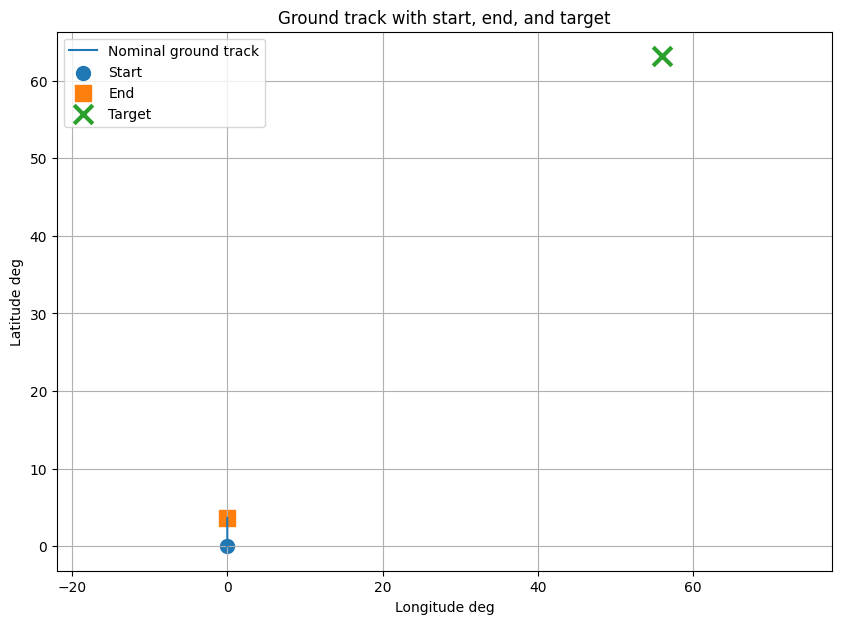

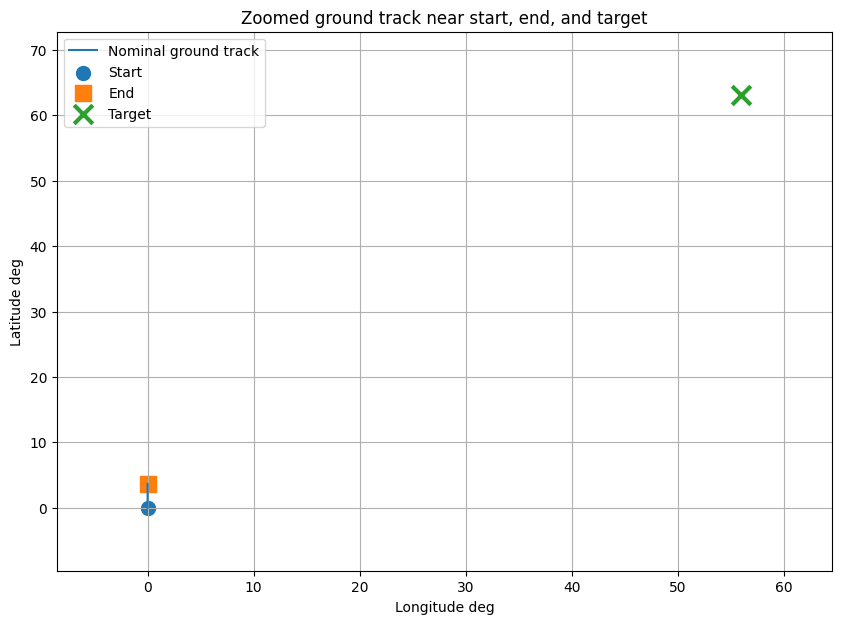

Start latitude deg 0.0
Start longitude deg 0.0
End latitude deg 3.639962586866068
End longitude deg -0.00800131832361189
Target latitude deg 63.152
Target longitude deg 55.96
North error m -6624811.26970341
East error m -2813757.151039365
Planar ground error m 7197593.602323937
Great circle surface error m 8015821.867521198


,start_lat_deg,start_lon_deg,end_lat_deg,end_lon_deg,target_lat_deg,target_lon_deg,north_error_m,east_error_m,planar_ground_error_m,great_circle_error_m
0,0.0,0.0,3.639963,-0.008001,63.152,55.96,-6.624811e+06,-2.813757e+06,7.197594e+06,8.015822e+06


In [429]:
# Ground track, target comparison, and landing error summary

if len(df) == 0:
    raise ValueError("The dataframe is empty. Run the main loop cell first.")

# Convert trajectory states to degrees for plotting
track_df = df.copy()
track_df["phi_deg"] = np.degrees(track_df["phi_rad"])
track_df["lam_deg"] = np.degrees(track_df["lam_rad"])

# Start and end points from the nominal path
start_phi_deg = float(track_df["phi_deg"].iloc[0])
start_lam_deg = float(track_df["lam_deg"].iloc[0])

end_phi_deg = float(track_df["phi_deg"].iloc[-1])
end_lam_deg = float(track_df["lam_deg"].iloc[-1])

# Target point in degrees
target_phi_deg = float(np.degrees(target_phi_rad))
target_lam_deg = float(np.degrees(target_lam_rad))

# Final nominal state error relative to target
R_earth_m = float(constants.RADIUS_EARTH)

dphi_rad = float(track_df["phi_rad"].iloc[-1] - target_phi_rad)
dlam_rad = float(track_df["lam_rad"].iloc[-1] - target_lam_rad)

north_error_m = R_earth_m * dphi_rad
east_error_m = R_earth_m * dlam_rad * math.cos(target_phi_rad)
ground_error_m = math.sqrt(north_error_m**2 + east_error_m**2)

# Great circle style angular distance and surface distance
sin_dphi_2 = math.sin(dphi_rad / 2.0)
sin_dlam_2 = math.sin(dlam_rad / 2.0)
a = (
    sin_dphi_2**2
    + math.cos(float(track_df["phi_rad"].iloc[-1])) * math.cos(target_phi_rad) * sin_dlam_2**2
)
a = min(1.0, max(0.0, a))
central_angle_rad = 2.0 * math.asin(math.sqrt(a))
great_circle_error_m = R_earth_m * central_angle_rad

# Plot the nominal ground track and mark start, end, and target
plt.figure(figsize=(10, 7))
plt.plot(track_df["lam_deg"], track_df["phi_deg"], label="Nominal ground track")
plt.scatter(start_lam_deg, start_phi_deg, s=100, marker="o", label="Start")
plt.scatter(end_lam_deg, end_phi_deg, s=120, marker="s", label="End")
plt.scatter(target_lam_deg, target_phi_deg, s=180, marker="x", linewidths=3, label="Target")

plt.xlabel("Longitude deg")
plt.ylabel("Latitude deg")
plt.title("Ground track with start, end, and target")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# Optional zoomed view around the target and end point
lon_vals = [start_lam_deg, end_lam_deg, target_lam_deg]
lat_vals = [start_phi_deg, end_phi_deg, target_phi_deg]

lon_pad = max(0.5, 0.15 * (max(lon_vals) - min(lon_vals) + 1.0))
lat_pad = max(0.5, 0.15 * (max(lat_vals) - min(lat_vals) + 1.0))

plt.figure(figsize=(10, 7))
plt.plot(track_df["lam_deg"], track_df["phi_deg"], label="Nominal ground track")
plt.scatter(start_lam_deg, start_phi_deg, s=100, marker="o", label="Start")
plt.scatter(end_lam_deg, end_phi_deg, s=120, marker="s", label="End")
plt.scatter(target_lam_deg, target_phi_deg, s=180, marker="x", linewidths=3, label="Target")

plt.xlim(min(lon_vals) - lon_pad, max(lon_vals) + lon_pad)
plt.ylim(min(lat_vals) - lat_pad, max(lat_vals) + lat_pad)

plt.xlabel("Longitude deg")
plt.ylabel("Latitude deg")
plt.title("Zoomed ground track near start, end, and target")
plt.legend()
plt.grid(True)
plt.show()

# Print a compact landing style summary
print("Start latitude deg", start_phi_deg)
print("Start longitude deg", start_lam_deg)
print("End latitude deg", end_phi_deg)
print("End longitude deg", end_lam_deg)
print("Target latitude deg", target_phi_deg)
print("Target longitude deg", target_lam_deg)
print("North error m", north_error_m)
print("East error m", east_error_m)
print("Planar ground error m", ground_error_m)
print("Great circle surface error m", great_circle_error_m)

# Tabular summary
landing_summary_df = pd.DataFrame(
    [
        {
            "start_lat_deg": start_phi_deg,
            "start_lon_deg": start_lam_deg,
            "end_lat_deg": end_phi_deg,
            "end_lon_deg": end_lam_deg,
            "target_lat_deg": target_phi_deg,
            "target_lon_deg": target_lam_deg,
            "north_error_m": north_error_m,
            "east_error_m": east_error_m,
            "planar_ground_error_m": ground_error_m,
            "great_circle_error_m": great_circle_error_m,
        }
    ]
)

landing_summary_df

# approx total nominal path travelled

In [430]:
# Approximate total nominal path length traveled

if len(df) < 2:
    raise ValueError("Need at least two trajectory rows in df")

R_earth_m = float(constants.RADIUS_EARTH)

segment_lengths_m = []

for i in range(1, len(df)):
    r1 = float(df.iloc[i - 1]["r_m"])
    r2 = float(df.iloc[i]["r_m"])

    phi1 = float(df.iloc[i - 1]["phi_rad"])
    phi2 = float(df.iloc[i]["phi_rad"])

    lam1 = float(df.iloc[i - 1]["lam_rad"])
    lam2 = float(df.iloc[i]["lam_rad"])

    x1 = r1 * math.cos(phi1) * math.cos(lam1)
    y1 = r1 * math.cos(phi1) * math.sin(lam1)
    z1 = r1 * math.sin(phi1)

    x2 = r2 * math.cos(phi2) * math.cos(lam2)
    y2 = r2 * math.cos(phi2) * math.sin(lam2)
    z2 = r2 * math.sin(phi2)

    ds = math.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)
    segment_lengths_m.append(ds)

total_distance_m = float(np.sum(segment_lengths_m))
total_distance_km = total_distance_m / 1000.0

print("Approximate total nominal path length m", total_distance_m)
print("Approximate total nominal path length km", total_distance_km)

Approximate total nominal path length m 412681.3439466236
Approximate total nominal path length km 412.6813439466236


# 3D trajectory

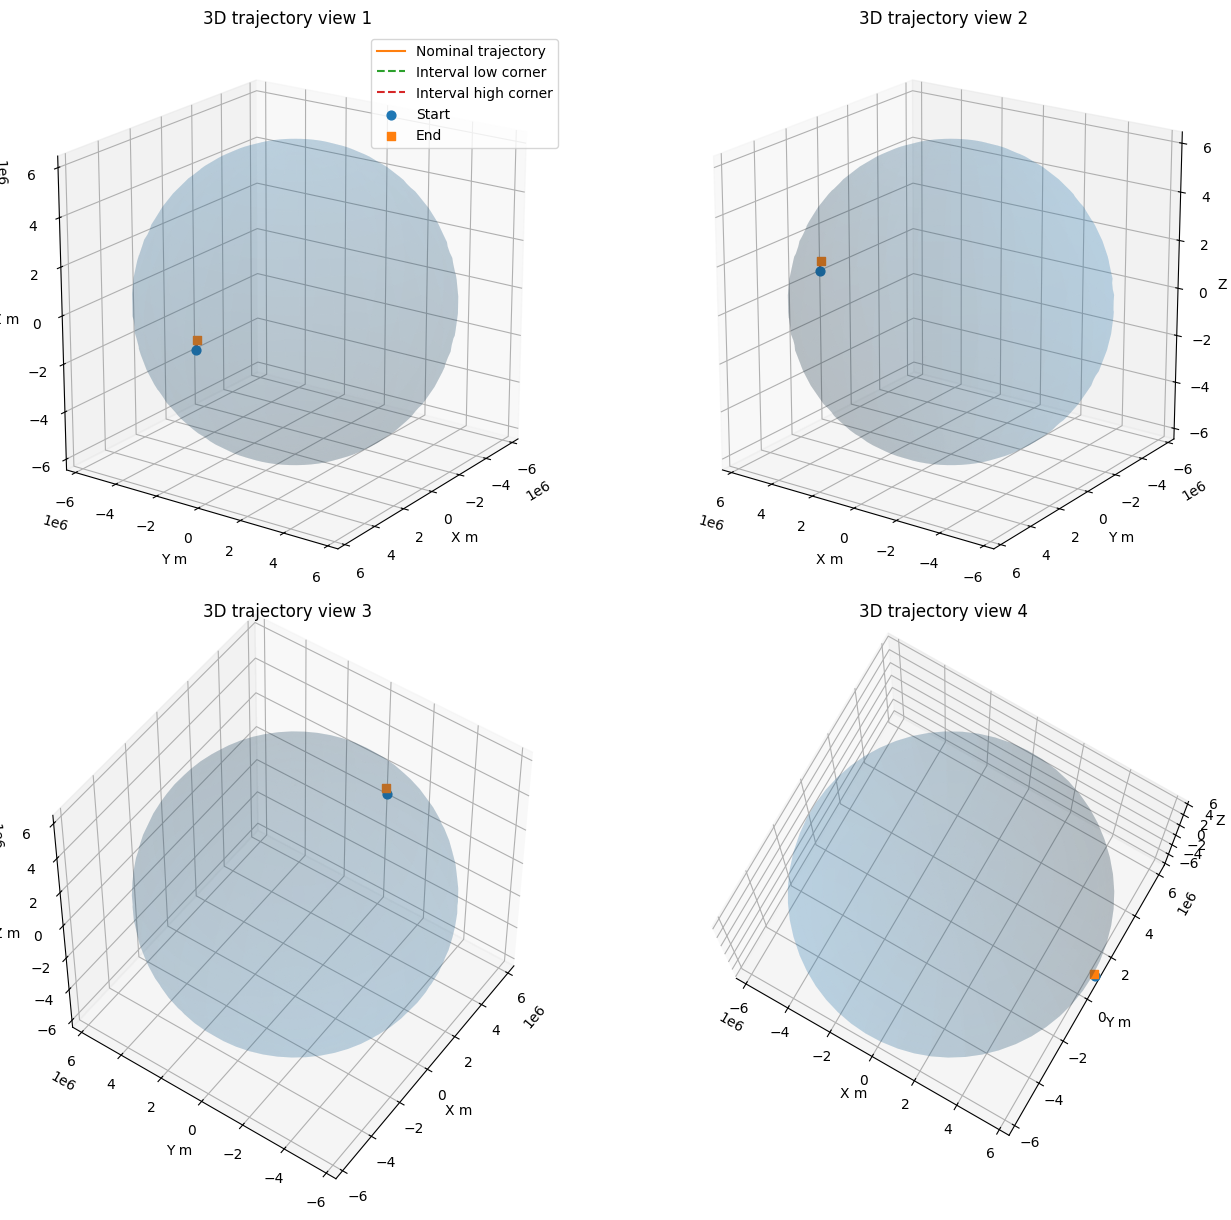

In [431]:
# 3D trajectory from four viewing angles with conservative interval corner curves

from mpl_toolkits.mplot3d import Axes3D

def spherical_to_cartesian(r, phi, lam):
    x = r * np.cos(phi) * np.cos(lam)
    y = r * np.cos(phi) * np.sin(lam)
    z = r * np.sin(phi)
    return x, y, z

# Nominal trajectory
r_nom = df["r_m"].to_numpy(dtype=float)
phi_nom = df["phi_rad"].to_numpy(dtype=float)
lam_nom = df["lam_rad"].to_numpy(dtype=float)

x_nom, y_nom, z_nom = spherical_to_cartesian(r_nom, phi_nom, lam_nom)

# Conservative interval corner trajectories
r_lo = df["r_m_lo"].to_numpy(dtype=float)
r_hi = df["r_m_hi"].to_numpy(dtype=float)

phi_lo = df["phi_rad_lo"].to_numpy(dtype=float)
phi_hi = df["phi_rad_hi"].to_numpy(dtype=float)

lam_lo = df["lam_rad_lo"].to_numpy(dtype=float)
lam_hi = df["lam_rad_hi"].to_numpy(dtype=float)

x_lo, y_lo, z_lo = spherical_to_cartesian(r_lo, phi_lo, lam_lo)
x_hi, y_hi, z_hi = spherical_to_cartesian(r_hi, phi_hi, lam_hi)

# Earth sphere for reference
u = np.linspace(0.0, 2.0 * np.pi, 60)
v = np.linspace(-0.5 * np.pi, 0.5 * np.pi, 30)
uu, vv = np.meshgrid(u, v)

x_e = R_earth_m * np.cos(vv) * np.cos(uu)
y_e = R_earth_m * np.cos(vv) * np.sin(uu)
z_e = R_earth_m * np.sin(vv)

fig = plt.figure(figsize=(14, 12))
views = [(20, 35), (20, 125), (50, 215), (80, 300)]

for idx, (elev, azim) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")

    ax.plot_surface(x_e, y_e, z_e, alpha=0.15, linewidth=0)

    ax.plot(x_nom, y_nom, z_nom, label="Nominal trajectory")
    ax.plot(x_lo, y_lo, z_lo, linestyle="--", label="Interval low corner")
    ax.plot(x_hi, y_hi, z_hi, linestyle="--", label="Interval high corner")

    ax.scatter(x_nom[0], y_nom[0], z_nom[0], marker="o", s=40, label="Start" if idx == 1 else None)
    ax.scatter(x_nom[-1], y_nom[-1], z_nom[-1], marker="s", s=40, label="End" if idx == 1 else None)

    ax.set_xlabel("X m")
    ax.set_ylabel("Y m")
    ax.set_zlabel("Z m")
    ax.set_title(f"3D trajectory view {idx}")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1, 1, 1))

    max_extent = np.max(np.abs(np.concatenate([x_nom, y_nom, z_nom, x_hi, y_hi, z_hi])))
    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)

    if idx == 1:
        ax.legend()

plt.tight_layout()
plt.show()

## more 3D views

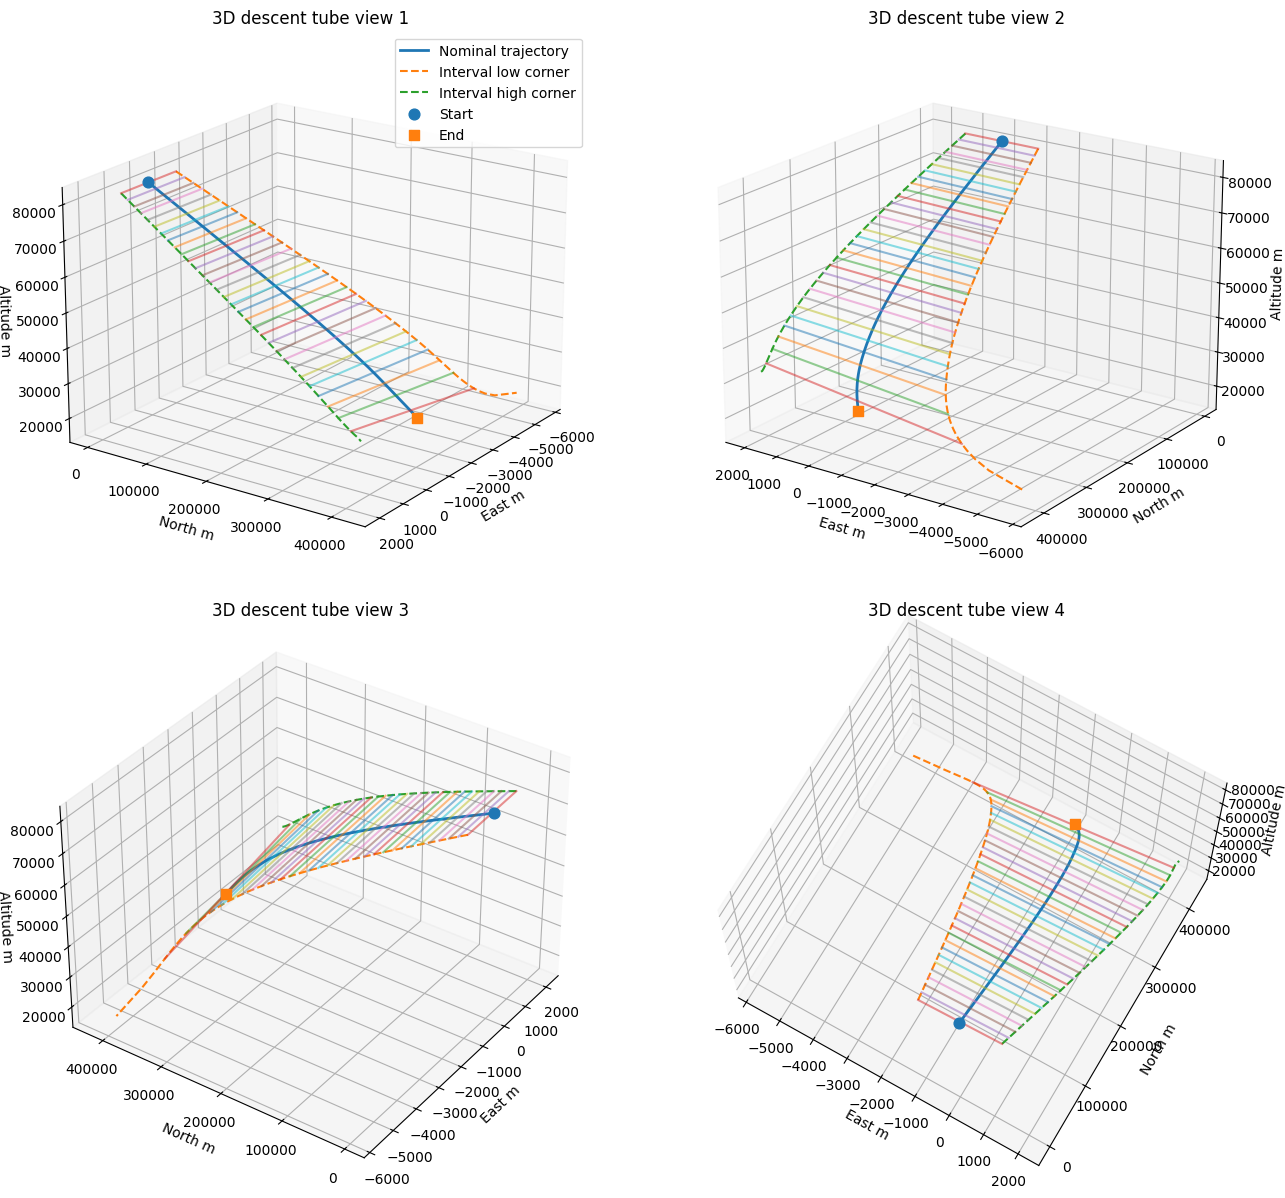

In [432]:
# 3D descent tube view centered on the trajectory instead of the whole Earth

if len(df) < 2:
    raise ValueError("Need at least two rows in df to plot the 3D trajectory")

R_earth_m = float(constants.RADIUS_EARTH)

# Use the first point as the local reference origin
phi0 = float(df["phi_rad"].iloc[0])
lam0 = float(df["lam_rad"].iloc[0])

# Local tangent plane approximation around the start point
# x_local points east
# y_local points north
# z_local is altitude

def local_track_from_lat_lon_alt(phi_rad, lam_rad, alt_m, phi_ref_rad, lam_ref_rad, R_m):
    east_m = R_m * (lam_rad - lam_ref_rad) * math.cos(phi_ref_rad)
    north_m = R_m * (phi_rad - phi_ref_rad)
    up_m = alt_m
    return east_m, north_m, up_m

# Nominal path
east_nom = []
north_nom = []
up_nom = []

# Interval low and high corner paths
east_lo = []
north_lo = []
up_lo = []

east_hi = []
north_hi = []
up_hi = []

for _, row in df.iterrows():
    e, n, u = local_track_from_lat_lon_alt(
        float(row["phi_rad"]),
        float(row["lam_rad"]),
        float(row["alt_m"]),
        phi0,
        lam0,
        R_earth_m,
    )
    east_nom.append(e)
    north_nom.append(n)
    up_nom.append(u)

    e_lo, n_lo, u_lo = local_track_from_lat_lon_alt(
        float(row["phi_rad_lo"]),
        float(row["lam_rad_lo"]),
        float(row["interval_alt_lo"]),
        phi0,
        lam0,
        R_earth_m,
    )
    east_lo.append(e_lo)
    north_lo.append(n_lo)
    up_lo.append(u_lo)

    e_hi, n_hi, u_hi = local_track_from_lat_lon_alt(
        float(row["phi_rad_hi"]),
        float(row["lam_rad_hi"]),
        float(row["interval_alt_hi"]),
        phi0,
        lam0,
        R_earth_m,
    )
    east_hi.append(e_hi)
    north_hi.append(n_hi)
    up_hi.append(u_hi)

east_nom = np.array(east_nom)
north_nom = np.array(north_nom)
up_nom = np.array(up_nom)

east_lo = np.array(east_lo)
north_lo = np.array(north_lo)
up_lo = np.array(up_lo)

east_hi = np.array(east_hi)
north_hi = np.array(north_hi)
up_hi = np.array(up_hi)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 12))
views = [(20, 35), (20, 125), (35, 215), (70, 300)]

for idx, (elev, azim) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")

    # Nominal trajectory
    ax.plot(east_nom, north_nom, up_nom, linewidth=2, label="Nominal trajectory")

    # Interval envelope as a tube-like band using the two corner curves
    ax.plot(east_lo, north_lo, up_lo, linestyle="--", label="Interval low corner")
    ax.plot(east_hi, north_hi, up_hi, linestyle="--", label="Interval high corner")

    # Connect low/high corners occasionally so the envelope looks more like a tube
    stride = max(1, len(df) // 30)
    for i in range(0, len(df), stride):
        ax.plot(
            [east_lo[i], east_hi[i]],
            [north_lo[i], north_hi[i]],
            [up_lo[i], up_hi[i]],
            alpha=0.5,
        )

    # Start and end markers
    ax.scatter(east_nom[0], north_nom[0], up_nom[0], s=60, marker="o", label="Start" if idx == 1 else None)
    ax.scatter(east_nom[-1], north_nom[-1], up_nom[-1], s=60, marker="s", label="End" if idx == 1 else None)

    ax.set_xlabel("East m")
    ax.set_ylabel("North m")
    ax.set_zlabel("Altitude m")
    ax.set_title(f"3D descent tube view {idx}")
    ax.view_init(elev=elev, azim=azim)

    if idx == 1:
        ax.legend()

plt.tight_layout()
plt.show()

## did guidance even activate

In [397]:
# Diagnose whether guidance is permanently disabled by the velocity gate

print("Minimum logged speed m/s:", df["V_mps"].min())
print("Maximum logged speed m/s:", df["V_mps"].max())
print("Any rows below 6000 m/s:", bool((df["V_mps"] <= 6000.0).any()))
print("Unique fired_this_step values:", sorted(df["fired_this_step"].unique()))
print("Max abs tau_roll_cmd_Nm:", float(np.abs(df["tau_roll_cmd_Nm"]).max()))
print("Max abs sigma_cmd_rad:", float(np.abs(df["sigma_cmd_rad"]).max()))
print("Max abs sigma_target_rad:", float(np.abs(df["sigma_target_rad"]).max()))

Minimum logged speed m/s: 7500.0
Maximum logged speed m/s: 10153.257021440324
Any rows below 6000 m/s: False
Unique fired_this_step values: [np.int64(0), np.int64(1)]
Max abs tau_roll_cmd_Nm: 5605.356188831755
Max abs sigma_cmd_rad: 1.2217304763960306
Max abs sigma_target_rad: 1.2217304763960306


In [398]:
# Check whether the guidance command is identically zero

df[
    [
        "t_s",
        "V_mps",
        "sigma_cmd_rad",
        "sigma_target_rad",
        "sigma_actual_rad",
        "tau_roll_cmd_Nm",
        "requested_duty",
        "fired_this_step",
    ]
].head(20)

,t_s,V_mps,sigma_cmd_rad,sigma_target_rad,sigma_actual_rad,tau_roll_cmd_Nm,requested_duty,fired_this_step
0,0.00,7500.000000,-1.22173,-0.043633,0.0000,-349.065850,0.061283,0
1,0.25,7500.354600,-1.22173,-0.130900,0.0000,-1047.197551,0.183848,0
2,0.50,7500.712913,-1.22173,-0.218166,0.0000,-1745.329252,0.306413,0
3,0.75,7501.075039,-1.22173,-0.305433,0.0000,-2443.460953,0.428978,0
4,1.00,7501.441082,-1.22173,-0.392699,-0.0178,-3141.592654,0.551544,1
5,1.25,7501.811129,-1.22173,-0.479966,-0.0534,-3412.524354,0.599109,1
6,1.50,7502.185167,-1.22173,-0.567232,-0.0890,-3541.056055,0.621674,0
7,1.75,7502.563157,-1.22173,-0.654498,-0.1424,-3954.387756,0.694239,1
8,2.00,7502.944774,-1.22173,-0.741765,-0.2136,-3940.519457,0.691805,1
9,2.25,7503.329327,-1.22173,-0.829031,-0.2848,-3784.251158,0.664370,0


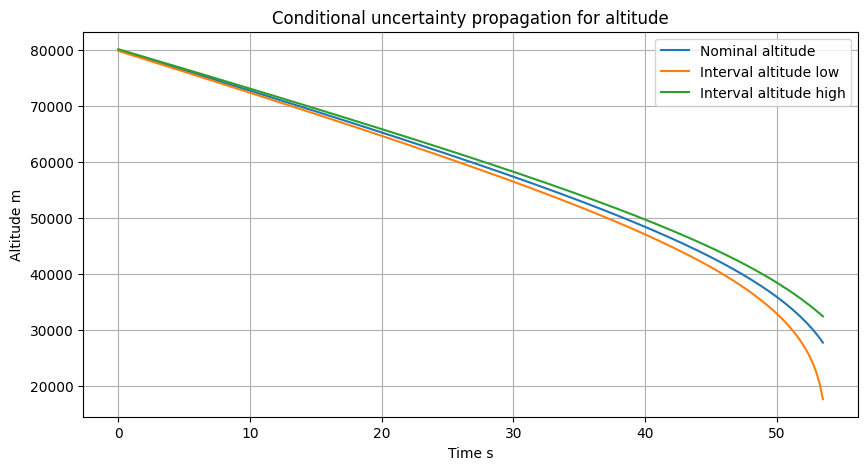

In [399]:
# Plot altitude with interval envelope

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["alt_m"], label="Nominal altitude")
plt.plot(df["t_s"], df["interval_alt_lo"], label="Interval altitude low")
plt.plot(df["t_s"], df["interval_alt_hi"], label="Interval altitude high")
plt.xlabel("Time s")
plt.ylabel("Altitude m")
plt.title("Conditional uncertainty propagation for altitude")
plt.legend()
plt.grid(True)
plt.show()

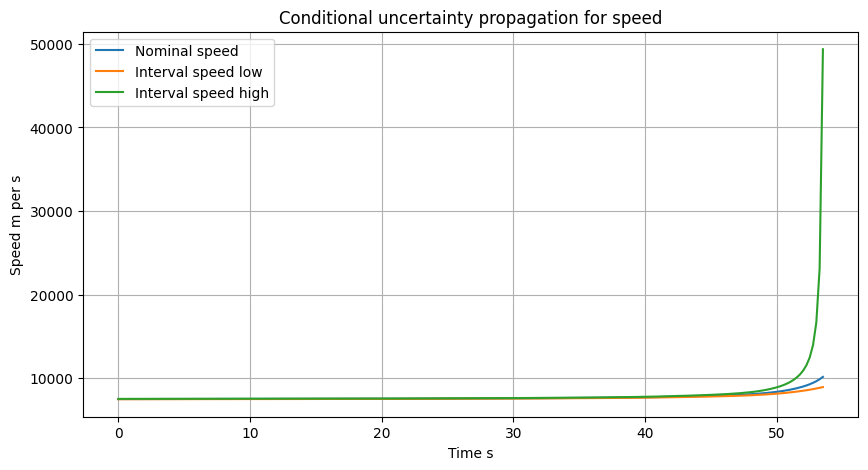

In [400]:
# Plot speed with interval envelope

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["V_mps"], label="Nominal speed")
plt.plot(df["t_s"], df["V_mps_lo"], label="Interval speed low")
plt.plot(df["t_s"], df["V_mps_hi"], label="Interval speed high")
plt.xlabel("Time s")
plt.ylabel("Speed m per s")
plt.title("Conditional uncertainty propagation for speed")
plt.legend()
plt.grid(True)
plt.show()

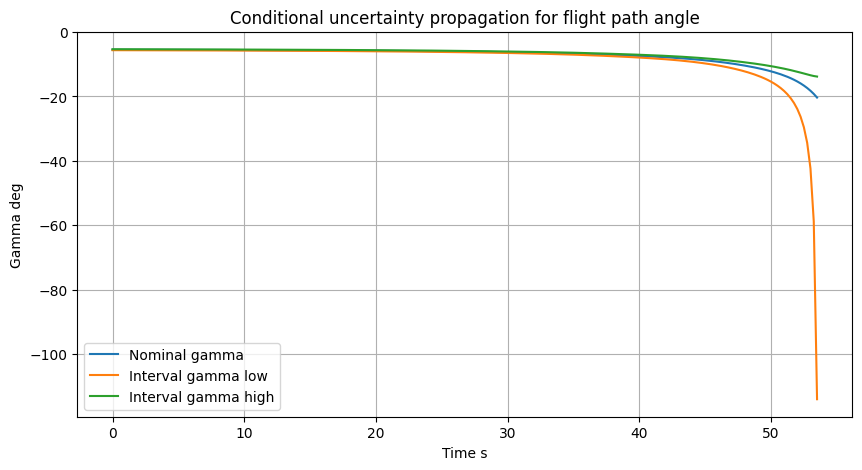

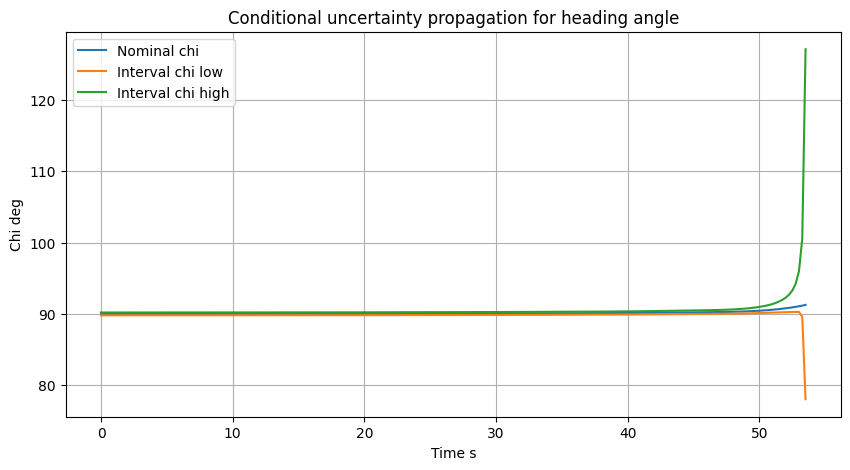

In [401]:
# Plot flight path angle and heading interval envelopes

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], np.degrees(df["gamma_rad"]), label="Nominal gamma")
plt.plot(df["t_s"], np.degrees(df["gamma_rad_lo"]), label="Interval gamma low")
plt.plot(df["t_s"], np.degrees(df["gamma_rad_hi"]), label="Interval gamma high")
plt.xlabel("Time s")
plt.ylabel("Gamma deg")
plt.title("Conditional uncertainty propagation for flight path angle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], np.degrees(df["chi_rad"]), label="Nominal chi")
plt.plot(df["t_s"], np.degrees(df["chi_rad_lo"]), label="Interval chi low")
plt.plot(df["t_s"], np.degrees(df["chi_rad_hi"]), label="Interval chi high")
plt.xlabel("Time s")
plt.ylabel("Chi deg")
plt.title("Conditional uncertainty propagation for heading angle")
plt.legend()
plt.grid(True)
plt.show()

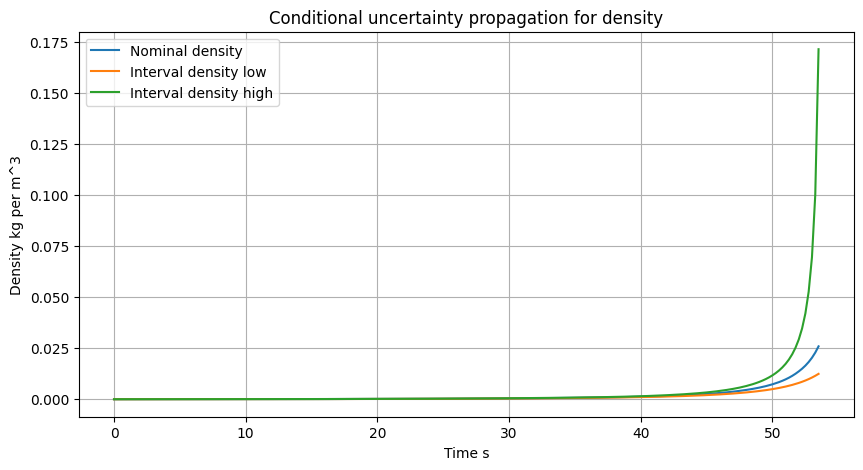

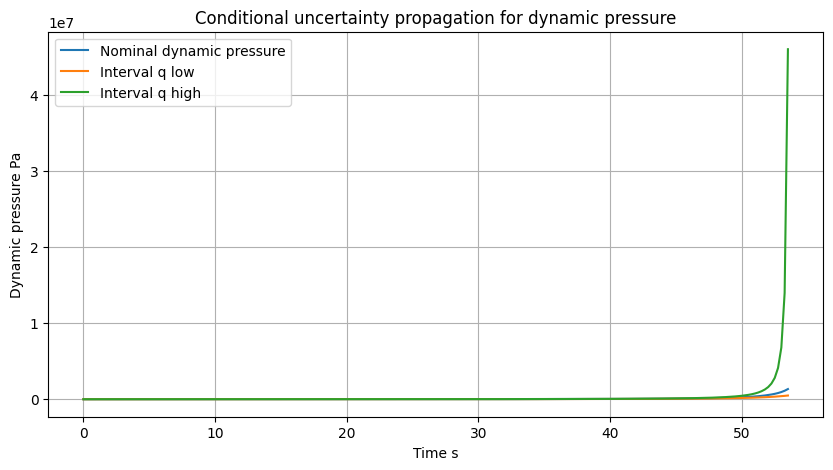

In [402]:
# Plot density and dynamic pressure interval envelopes

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["rho_kgm3"], label="Nominal density")
plt.plot(df["t_s"], df["interval_rho_lo"], label="Interval density low")
plt.plot(df["t_s"], df["interval_rho_hi"], label="Interval density high")
plt.xlabel("Time s")
plt.ylabel("Density kg per m^3")
plt.title("Conditional uncertainty propagation for density")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["q_pa"], label="Nominal dynamic pressure")
plt.plot(df["t_s"], df["interval_q_lo"], label="Interval q low")
plt.plot(df["t_s"], df["interval_q_hi"], label="Interval q high")
plt.xlabel("Time s")
plt.ylabel("Dynamic pressure Pa")
plt.title("Conditional uncertainty propagation for dynamic pressure")
plt.legend()
plt.grid(True)
plt.show()

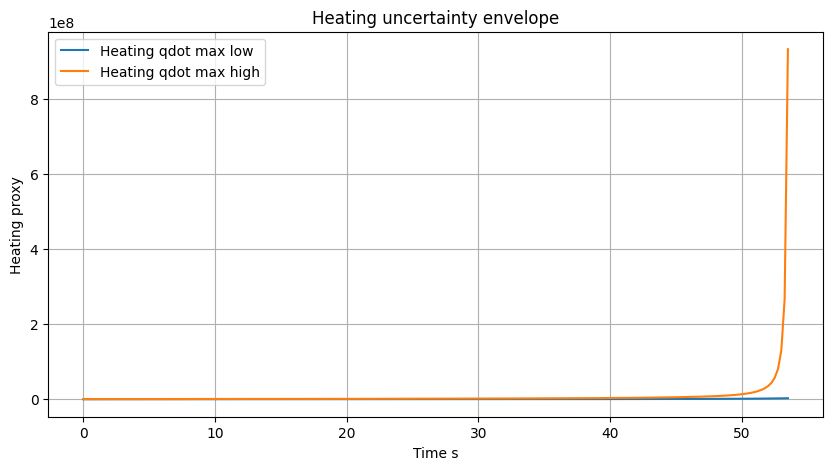

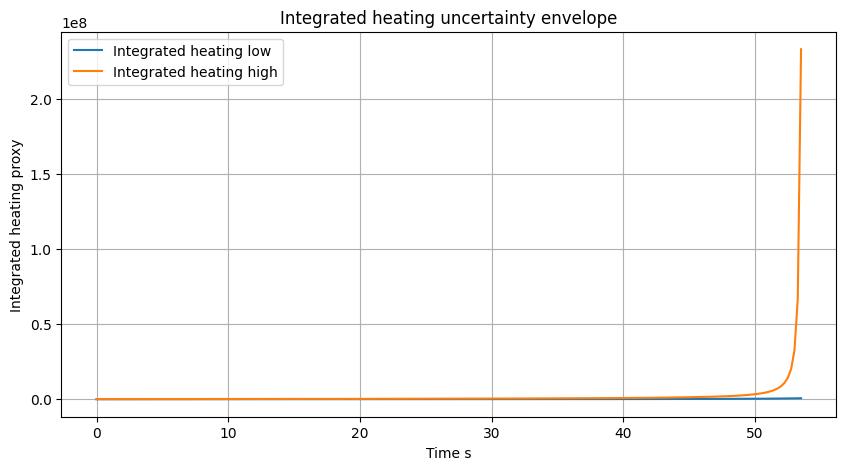

In [403]:
# Plot heating uncertainty

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["heating_qdot_max_lo"], label="Heating qdot max low")
plt.plot(df["t_s"], df["heating_qdot_max_hi"], label="Heating qdot max high")
plt.xlabel("Time s")
plt.ylabel("Heating proxy")
plt.title("Heating uncertainty envelope")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["heating_Q_max_lo"], label="Integrated heating low")
plt.plot(df["t_s"], df["heating_Q_max_hi"], label="Integrated heating high")
plt.xlabel("Time s")
plt.ylabel("Integrated heating proxy")
plt.title("Integrated heating uncertainty envelope")
plt.legend()
plt.grid(True)
plt.show()

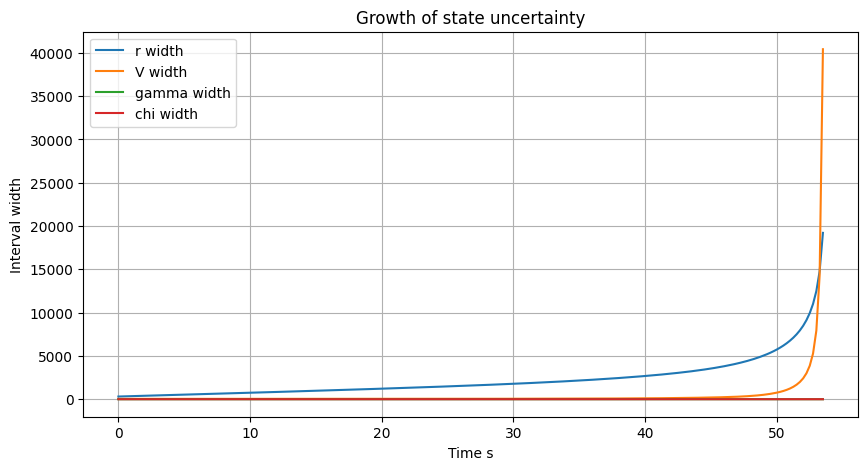

In [404]:
# Plot state widths directly

# This makes uncertainty growth easier to see than plotting against large nominal scales.

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["width_r_m"], label="r width")
plt.plot(df["t_s"], df["width_V_mps"], label="V width")
plt.plot(df["t_s"], df["width_gamma_rad"], label="gamma width")
plt.plot(df["t_s"], df["width_chi_rad"], label="chi width")
plt.xlabel("Time s")
plt.ylabel("Interval width")
plt.title("Growth of state uncertainty")
plt.legend()
plt.grid(True)
plt.show()

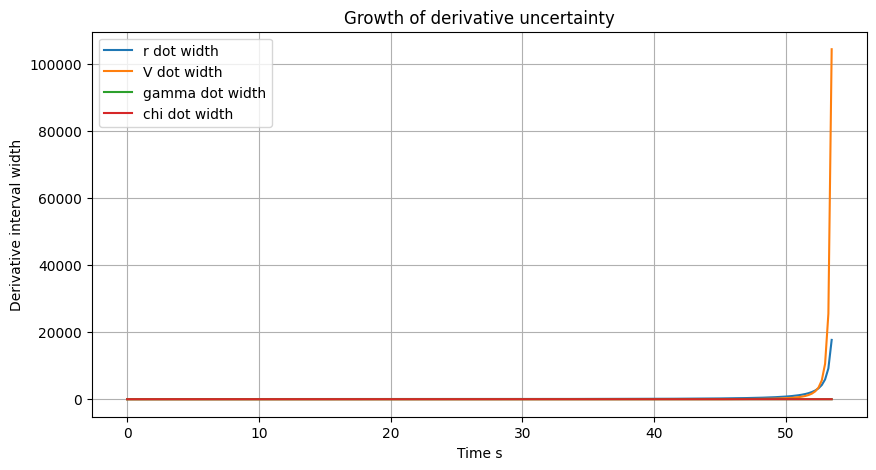

In [405]:
# Plot derivative widths directly

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["dx_width_r"], label="r dot width")
plt.plot(df["t_s"], df["dx_width_V"], label="V dot width")
plt.plot(df["t_s"], df["dx_width_gamma"], label="gamma dot width")
plt.plot(df["t_s"], df["dx_width_chi"], label="chi dot width")
plt.xlabel("Time s")
plt.ylabel("Derivative interval width")
plt.title("Growth of derivative uncertainty")
plt.legend()
plt.grid(True)
plt.show()

In [406]:
# Quick safety status summary

df["safety_status"].value_counts(dropna=False)

safety_status
inside    215
Name: count, dtype: int64

In [407]:
# Show rows where the safety status is not fully inside

df[df["safety_status"] != "inside"][
    [
        "t_s",
        "alt_m",
        "V_mps",
        "q_pa",
        "interval_alt_lo",
        "interval_alt_hi",
        "interval_q_lo",
        "interval_q_hi",
        "safety_status",
        "safety_checks",
    ]
].head(20)

,t_s,alt_m,V_mps,q_pa,interval_alt_lo,interval_alt_hi,interval_q_lo,interval_q_hi,safety_status,safety_checks


### It means the propagated interval box now partly satisfies a limit and partly violates it. So within the uncertainty envelope, some possible states are still inside the allowed region and some are outside

In [408]:
# Save outputs for later review

output_csv = "conditional_uncertainty_propagation_log.csv"
df.to_csv(output_csv, index=False)
print("Saved", output_csv)

Saved conditional_uncertainty_propagation_log.csv


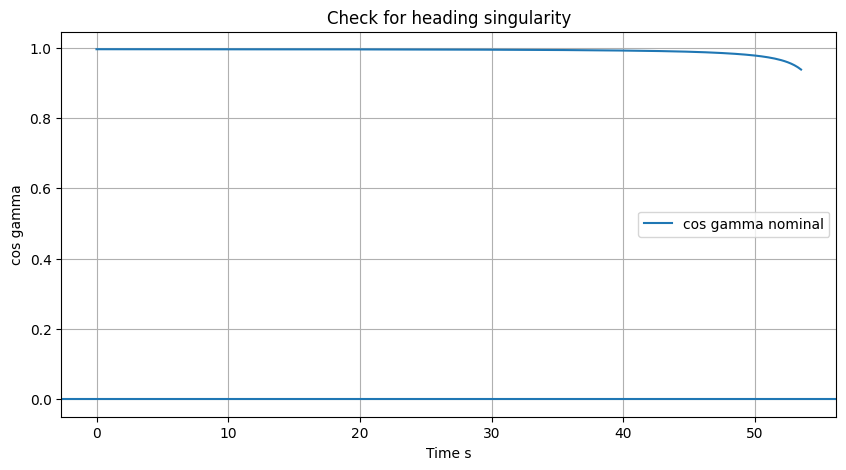

In [409]:
# Check for heading singularity using the current logged gamma column

plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], np.cos(df["gamma_rad"]), label="cos gamma nominal")
plt.axhline(0.0)
plt.xlabel("Time s")
plt.ylabel("cos gamma")
plt.title("Check for heading singularity")
plt.legend()
plt.grid(True)
plt.show()

# PLot Nominal and Interval Trajectory before blowup

Last safe index 202
Last safe time s 50.5
Last safe nominal altitude m 35036.562763596885
Last safe nominal gamma deg -12.810515854884779
Last safe cos gamma 0.9751086756919419


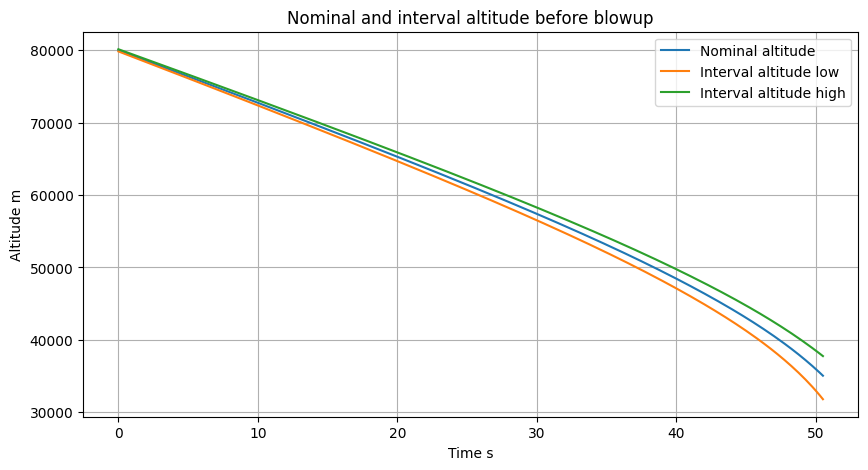

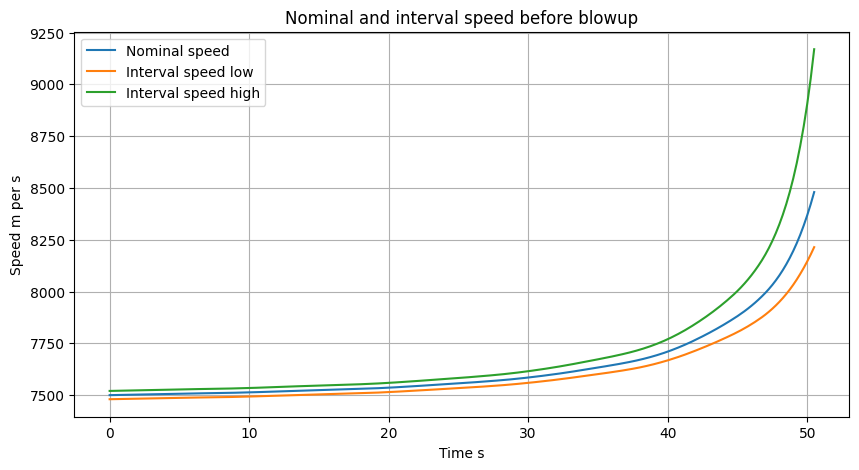

In [410]:
# Plot only the nominal and interval trajectory before the late stage blowup

# This cell finds the last safe time index before the heading equation becomes unstable.
# The cutoff uses several conditions so the displayed trajectory stays in the regime
# where the interval supervisor is still meaningful.

cos_gamma_floor = 0.2
max_speed_width = 1.0e4
max_gamma_width = 0.1
max_chi_width = 0.1

safe_mask = (
    (np.abs(np.cos(df["gamma_rad"])) >= cos_gamma_floor) &
    (df["width_V_mps"] <= max_speed_width) &
    (df["width_gamma_rad"] <= max_gamma_width) &
    (df["width_chi_rad"] <= max_chi_width)
)

if not safe_mask.any():
    raise ValueError("No safe rows found with the current cutoff settings")

last_safe_idx = df.index[safe_mask][-1]
df_pre_blowup = df.loc[:last_safe_idx].copy()
df_pre_blowup["gamma_deg"] = np.degrees(df_pre_blowup["gamma_rad"])

print("Last safe index", last_safe_idx)
print("Last safe time s", df_pre_blowup["t_s"].iloc[-1])
print("Last safe nominal altitude m", df_pre_blowup["alt_m"].iloc[-1])
print("Last safe nominal gamma deg", df_pre_blowup["gamma_deg"].iloc[-1])
print("Last safe cos gamma", math.cos(df_pre_blowup["gamma_rad"].iloc[-1]))

plt.figure(figsize=(10, 5))
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["alt_m"], label="Nominal altitude")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["interval_alt_lo"], label="Interval altitude low")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["interval_alt_hi"], label="Interval altitude high")
plt.xlabel("Time s")
plt.ylabel("Altitude m")
plt.title("Nominal and interval altitude before blowup")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["V_mps"], label="Nominal speed")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["V_mps_lo"], label="Interval speed low")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["V_mps_hi"], label="Interval speed high")
plt.xlabel("Time s")
plt.ylabel("Speed m per s")
plt.title("Nominal and interval speed before blowup")
plt.legend()
plt.grid(True)
plt.show()

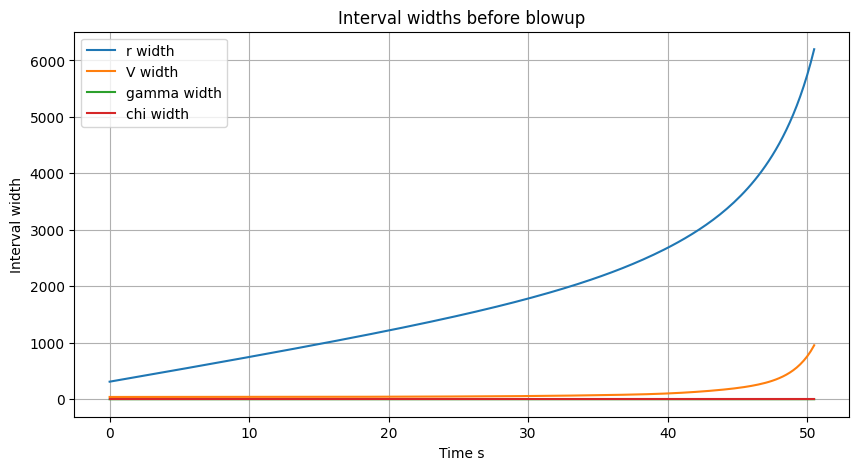

       t_s    width_r_m  width_V_mps  width_gamma_rad  width_chi_rad
193  48.25  4645.126893   402.150088         0.052186       0.010733
194  48.50  4768.959458   434.256576         0.055409       0.011091
195  48.75  4901.608489   470.949417         0.058958       0.011512
196  49.00  5044.144101   513.082210         0.062882       0.012008
197  49.25  5197.827945   561.717752         0.067240       0.012597
198  49.50  5364.160344   618.194112         0.072107       0.013300
199  49.75  5544.942610   683.472947         0.077621       0.014114
200  50.00  5742.408264   759.544555         0.083908       0.015067
201  50.25  5959.300289   849.019155         0.091133       0.016192
202  50.50  6199.033136   955.383484         0.099507       0.017535


In [411]:
# Show interval widths directly so they are not hidden by the large nominal scales

plt.figure(figsize=(10, 5))
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["width_r_m"], label="r width")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["width_V_mps"], label="V width")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["width_gamma_rad"], label="gamma width")
plt.plot(df_pre_blowup["t_s"], df_pre_blowup["width_chi_rad"], label="chi width")
plt.xlabel("Time s")
plt.ylabel("Interval width")
plt.title("Interval widths before blowup")
plt.legend()
plt.grid(True)
plt.show()

print(df_pre_blowup[
    [
        "t_s",
        "width_r_m",
        "width_V_mps",
        "width_gamma_rad",
        "width_chi_rad",
    ]
].tail(10))

# Reaction Control System (RCS) analysis

In [412]:
# Add degree based convenience columns for control diagnostics

df["sigma_cmd_deg"] = np.degrees(df["sigma_cmd_rad"])
df["sigma_target_deg"] = np.degrees(df["sigma_target_rad"])
df["sigma_actual_deg"] = np.degrees(df["sigma_actual_rad"])
df["roll_rate_deg_s"] = np.degrees(df["roll_rate_rad_s"])
df["roll_accel_deg_s2"] = np.degrees(df["roll_accel_rad_s2"])

df[
    [
        "t_s",
        "sigma_cmd_deg",
        "sigma_target_deg",
        "sigma_actual_deg",
        "roll_rate_deg_s",
        "tau_roll_cmd_Nm",
        "requested_duty",
        "fired_this_step",
        "active_thrusters",
        "torque_z_from_rcs",
    ]
].head(12)

,t_s,sigma_cmd_deg,sigma_target_deg,sigma_actual_deg,roll_rate_deg_s,tau_roll_cmd_Nm,requested_duty,fired_this_step,active_thrusters,torque_z_from_rcs
0,0.00,-70.0,-2.5,0.000000,0.000000,-349.065850,0.061283,0,,0.0
1,0.25,-70.0,-7.5,0.000000,0.000000,-1047.197551,0.183848,0,,0.0
2,0.50,-70.0,-12.5,0.000000,0.000000,-1745.329252,0.306413,0,,0.0
3,0.75,-70.0,-17.5,0.000000,0.000000,-2443.460953,0.428978,0,,0.0
4,1.00,-70.0,-22.5,-1.019865,-4.079460,-3141.592654,0.551544,1,"POD0_RNEG,POD1_RNEG,POD2_RNEG,POD3_RNEG",-5696.0
5,1.25,-70.0,-27.5,-3.059595,-8.158919,-3412.524354,0.599109,1,"POD0_RNEG,POD1_RNEG,POD2_RNEG,POD3_RNEG",-5696.0
6,1.50,-70.0,-32.5,-5.099324,-8.158919,-3541.056055,0.621674,0,,0.0
7,1.75,-70.0,-37.5,-8.158919,-12.238379,-3954.387756,0.694239,1,"POD0_RNEG,POD1_RNEG,POD2_RNEG,POD3_RNEG",-5696.0
8,2.00,-70.0,-42.5,-12.238379,-16.317838,-3940.519457,0.691805,1,"POD0_RNEG,POD1_RNEG,POD2_RNEG,POD3_RNEG",-5696.0
9,2.25,-70.0,-47.5,-16.317838,-16.317838,-3784.251158,0.664370,0,,0.0


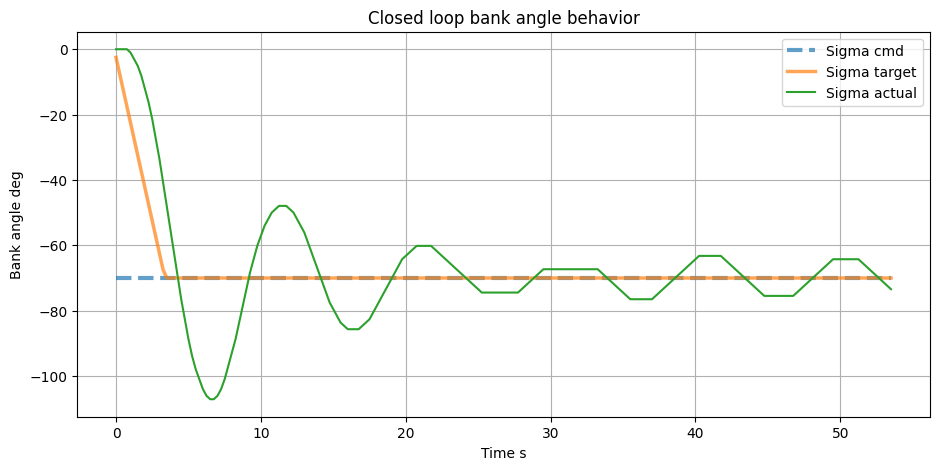

In [426]:
# Initialize a new figure with specific dimensions for the plot
plt.figure(figsize=(11, 5))

# Plot the commanded bank angle with a dashed line and increased width to prevent it from being hidden
plt.plot(df["t_s"], df["sigma_cmd_deg"], label="Sigma cmd", linestyle="dashed", linewidth=3.0, alpha=0.7)

# Plot the smoothed target bank angle with a dotted line
plt.plot(df["t_s"], df["sigma_target_deg"], label="Sigma target", linewidth=2.5, alpha=0.7)

# Plot the actual flown bank angle with a standard solid line
plt.plot(df["t_s"], df["sigma_actual_deg"], label="Sigma actual", linewidth=1.5)

# Apply text labels to both the horizontal and vertical axes
plt.xlabel("Time s")
plt.ylabel("Bank angle deg")

# Set the main title for the graph
plt.title("Closed loop bank angle behavior")

# Insert a legend to clearly identify each variable
plt.legend()

# Enable the background grid for easier visual tracking of values
plt.grid(True)

# Render and display the completed plot
plt.show()

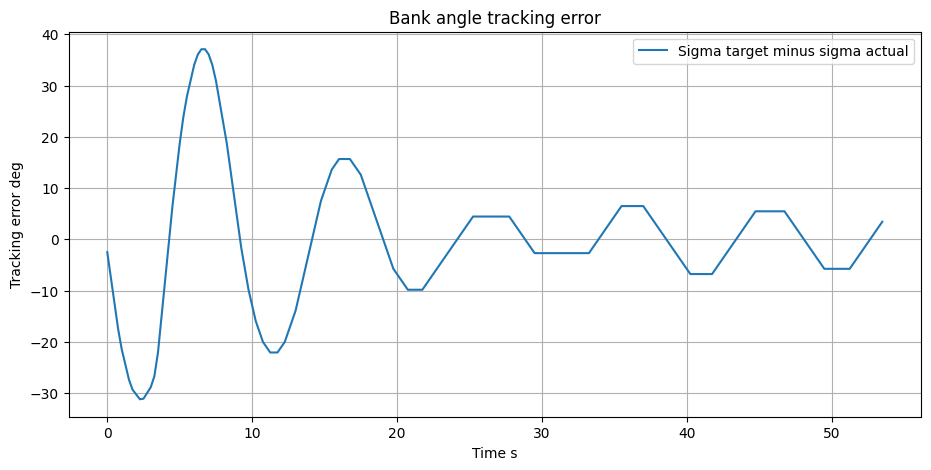

In [427]:
# Plot actual bank tracking error

tracking_error_deg = df["sigma_target_deg"] - df["sigma_actual_deg"]

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], tracking_error_deg, label="Sigma target minus sigma actual")
plt.xlabel("Time s")
plt.ylabel("Tracking error deg")
plt.title("Bank angle tracking error")
plt.legend()
plt.grid(True)
plt.show()

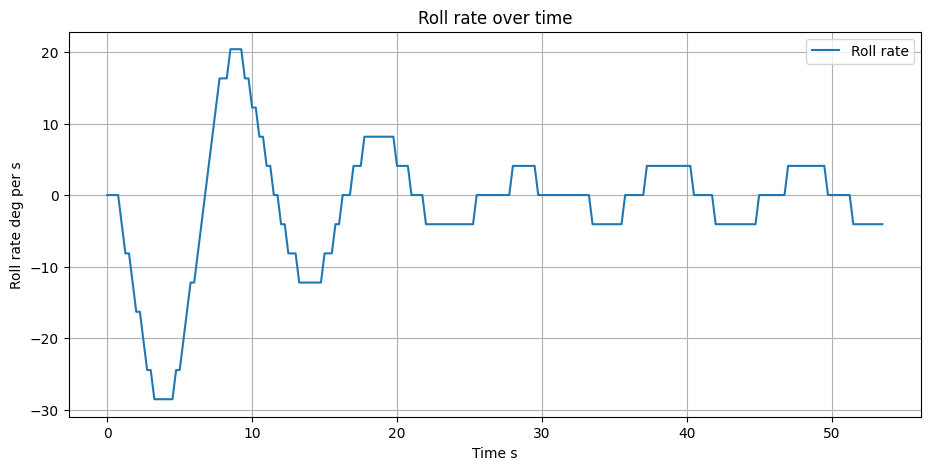

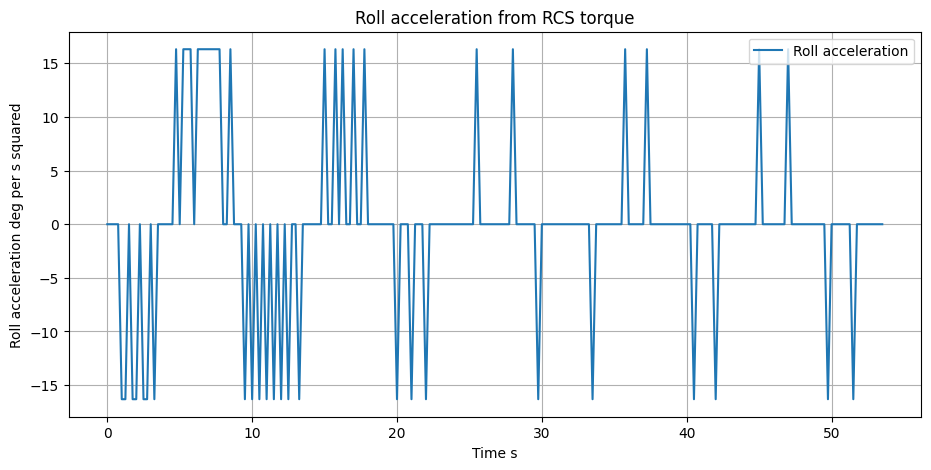

In [428]:
# Plot roll rate and roll acceleration

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["roll_rate_deg_s"], label="Roll rate")
plt.xlabel("Time s")
plt.ylabel("Roll rate deg per s")
plt.title("Roll rate over time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["roll_accel_deg_s2"], label="Roll acceleration")
plt.xlabel("Time s")
plt.ylabel("Roll acceleration deg per s squared")
plt.title("Roll acceleration from RCS torque")
plt.legend()
plt.grid(True)
plt.show()

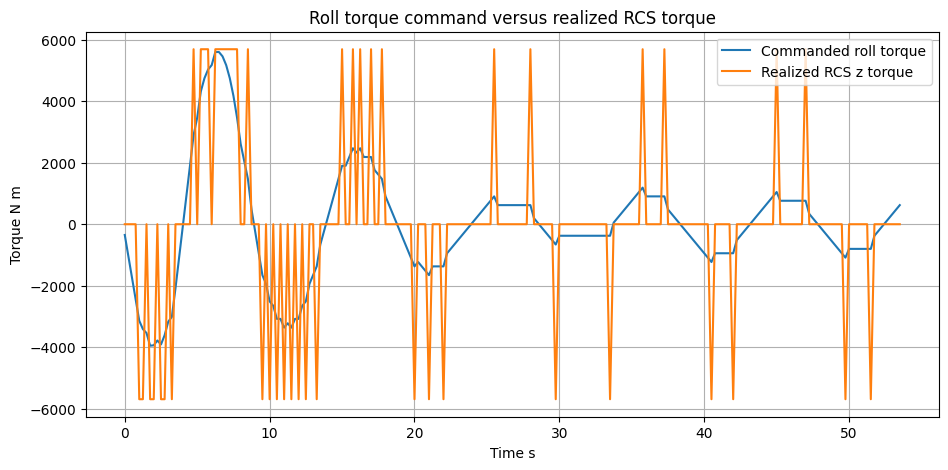

In [416]:
# Plot commanded roll torque and realized RCS roll torque

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["tau_roll_cmd_Nm"], label="Commanded roll torque")
plt.plot(df["t_s"], df["torque_z_from_rcs"], label="Realized RCS z torque")
plt.xlabel("Time s")
plt.ylabel("Torque N m")
plt.title("Roll torque command versus realized RCS torque")
plt.legend()
plt.grid(True)
plt.show()

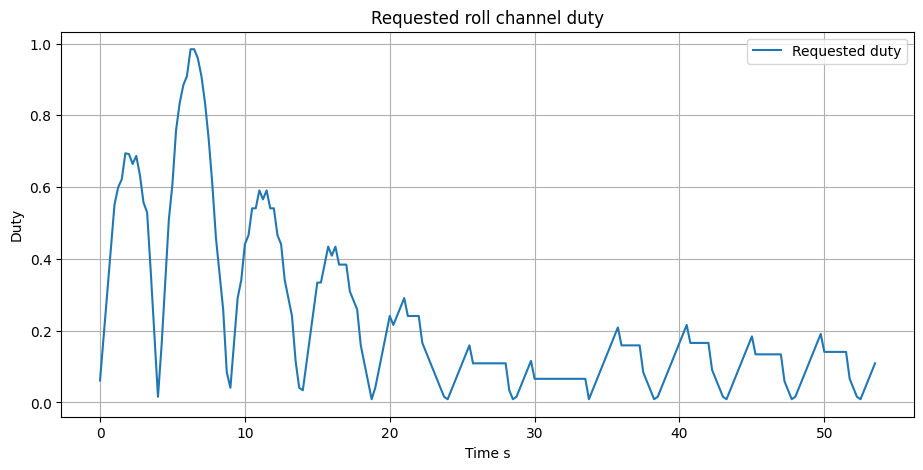

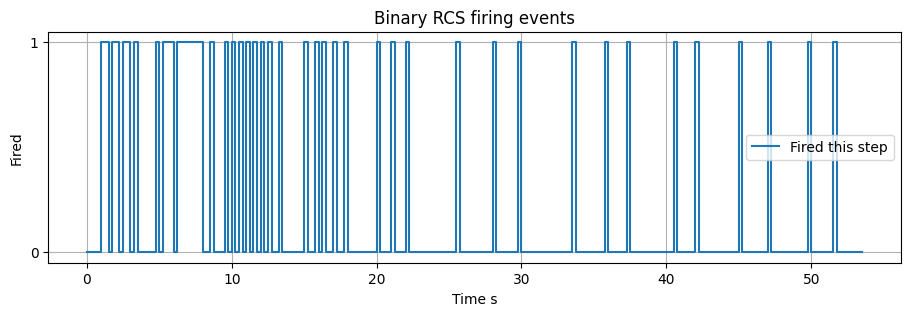

In [417]:
# Plot requested duty and whether a firing actually happened this step

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["requested_duty"], label="Requested duty")
plt.xlabel("Time s")
plt.ylabel("Duty")
plt.title("Requested roll channel duty")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 3))
plt.step(df["t_s"], df["fired_this_step"], where="post", label="Fired this step")
plt.xlabel("Time s")
plt.ylabel("Fired")
plt.title("Binary RCS firing events")
plt.yticks([0, 1])
plt.legend()
plt.grid(True)
plt.show()

In [418]:
# Expand active thrusters into one row per thruster firing event

thruster_event_rows = []

for _, row in df.iterrows():
    active_str = row["active_thrusters"]

    if pd.isna(active_str):
        continue

    active_str = str(active_str).strip()
    if active_str == "":
        continue

    active_list = [name.strip() for name in active_str.split(",") if name.strip()]

    for thr_name in active_list:
        thruster_event_rows.append(
            {
                "t_s": float(row["t_s"]),
                "thruster": thr_name,
                "requested_duty": float(row["requested_duty"]),
                "tau_roll_cmd_Nm": float(row["tau_roll_cmd_Nm"]),
                "torque_z_from_rcs": float(row["torque_z_from_rcs"]),
            }
        )

thruster_events_df = pd.DataFrame(thruster_event_rows)

print("Number of thruster firing records", len(thruster_events_df))
thruster_events_df.head(20)

Number of thruster firing records 188


,t_s,thruster,requested_duty,tau_roll_cmd_Nm,torque_z_from_rcs
0,1.00,POD0_RNEG,0.551544,-3141.592654,-5696.0
1,1.00,POD1_RNEG,0.551544,-3141.592654,-5696.0
2,1.00,POD2_RNEG,0.551544,-3141.592654,-5696.0
3,1.00,POD3_RNEG,0.551544,-3141.592654,-5696.0
4,1.25,POD0_RNEG,0.599109,-3412.524354,-5696.0
5,1.25,POD1_RNEG,0.599109,-3412.524354,-5696.0
6,1.25,POD2_RNEG,0.599109,-3412.524354,-5696.0
7,1.25,POD3_RNEG,0.599109,-3412.524354,-5696.0
8,1.75,POD0_RNEG,0.694239,-3954.387756,-5696.0
9,1.75,POD1_RNEG,0.694239,-3954.387756,-5696.0


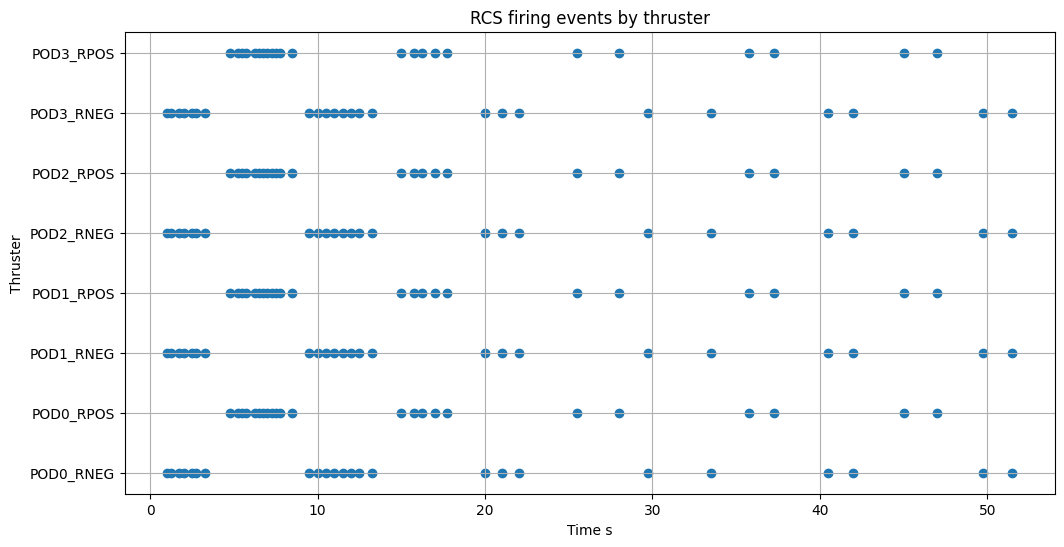

In [419]:
# Scatter plot of which thrusters fired and when

if len(thruster_events_df) == 0:
    print("No thruster firing events were logged")
else:
    thruster_names = sorted(thruster_events_df["thruster"].unique())
    thruster_to_y = {name: idx for idx, name in enumerate(thruster_names)}

    y_vals = thruster_events_df["thruster"].map(thruster_to_y)

    plt.figure(figsize=(12, 6))
    plt.scatter(thruster_events_df["t_s"], y_vals)
    plt.xlabel("Time s")
    plt.ylabel("Thruster")
    plt.title("RCS firing events by thruster")
    plt.yticks(list(thruster_to_y.values()), list(thruster_to_y.keys()))
    plt.grid(True)
    plt.show()

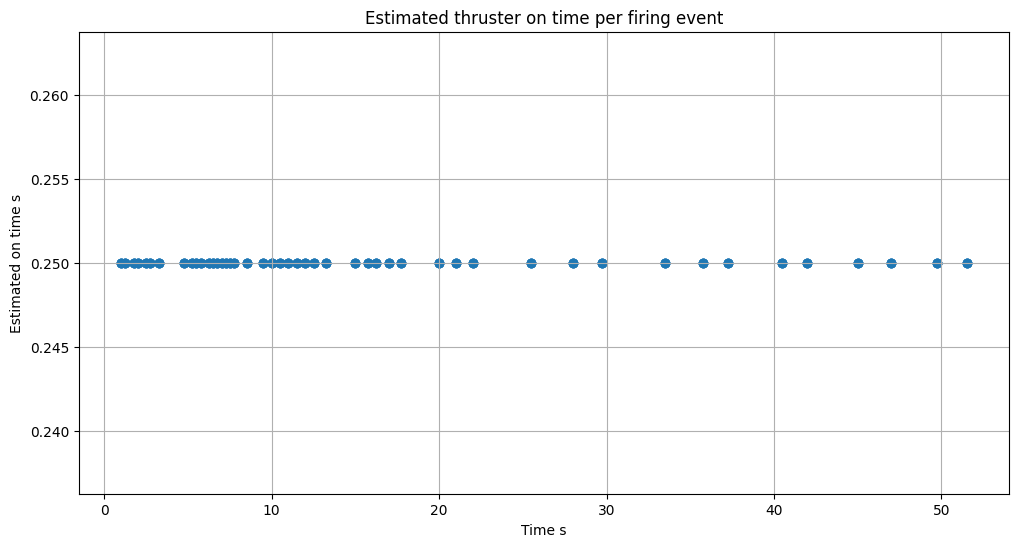

In [420]:
# Estimated on time per active thruster during each step

# This is estimated on time per active thruster during the step.
# In this milestone 1 model, a firing step means the channel fired for the full dt.
# The requested duty still shows the fractional demand before pulse accumulation.

if len(thruster_events_df) == 0:
    print("No thruster firing events were logged")
else:
    thruster_events_df["estimated_on_time_s"] = dt_s

    plt.figure(figsize=(12, 6))
    plt.scatter(
        thruster_events_df["t_s"],
        thruster_events_df["estimated_on_time_s"],
    )
    plt.xlabel("Time s")
    plt.ylabel("Estimated on time s")
    plt.title("Estimated thruster on time per firing event")
    plt.grid(True)
    plt.show()

##  Requested duty versus actual firing events
## Duty = is the fraction of full roll-channel capability the controller is requesting at that moment

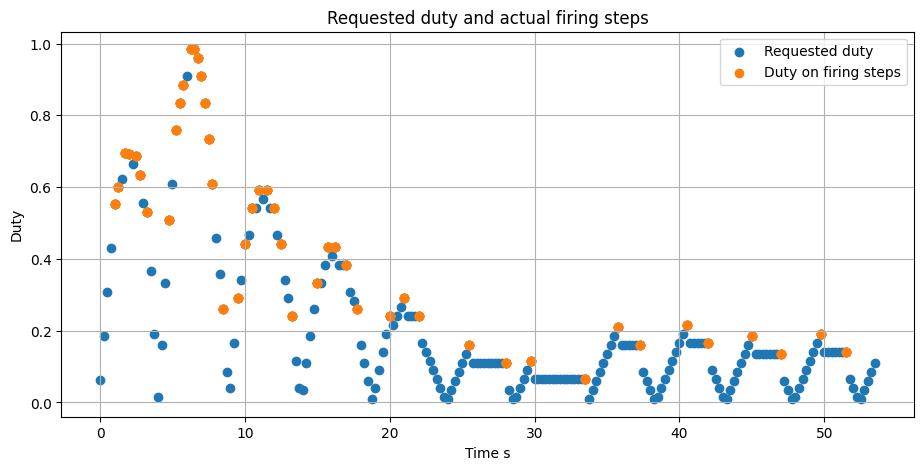

In [421]:
# Requested duty versus actual firing events

if len(thruster_events_df) == 0:
    print("No thruster firing events were logged")
else:
    plt.figure(figsize=(11, 5))
    plt.scatter(df["t_s"], df["requested_duty"], label="Requested duty")
    plt.scatter(
        thruster_events_df["t_s"],
        thruster_events_df["requested_duty"],
        label="Duty on firing steps",
    )
    plt.xlabel("Time s")
    plt.ylabel("Duty")
    plt.title("Requested duty and actual firing steps")
    plt.legend()
    plt.grid(True)
    plt.show()

### The system converts continuous demand into discrete pulses
#### This graph shows how continuous roll torque demand is converted into discrete full-power RCS pulses over time, with firing frequency decreasing as the system stabilizes.
### System demands fractional pulse (i.e 0.3 of a pulse right now)
### But the system can only do 0 or 1 full pulse
### So it waits and accumulates until it has enough (>= 1), then fires

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Rolling summary of firing frequency

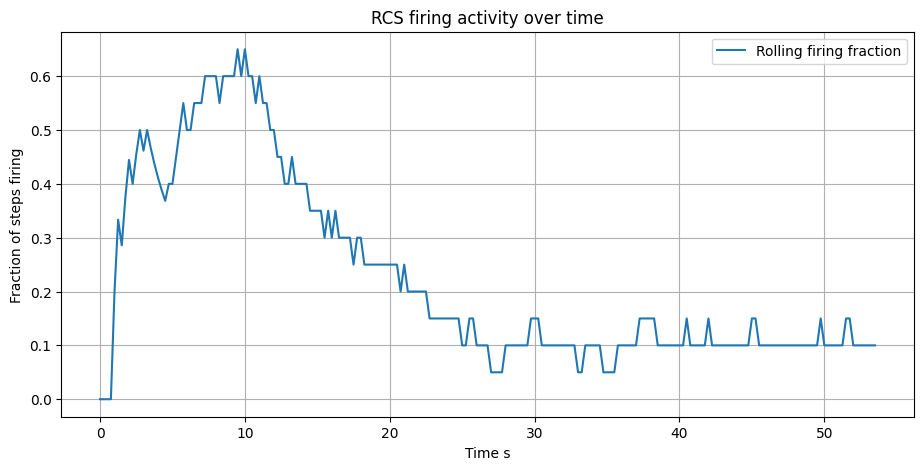

In [422]:
# Rolling summary of firing frequency

window_steps = 20

df["firing_rate_window"] = df["fired_this_step"].rolling(window_steps, min_periods=1).mean()

plt.figure(figsize=(11, 5))
plt.plot(df["t_s"], df["firing_rate_window"], label="Rolling firing fraction")
plt.xlabel("Time s")
plt.ylabel("Fraction of steps firing")
plt.title("RCS firing activity over time")
plt.legend()
plt.grid(True)
plt.show()

## final compact view

In [423]:
# Final compact view of the last few valid rows

summary_cols = [
    "t_s",
    "alt_m",
    "V_mps",
    "gamma_rad",
    "sigma_actual_deg",
    "width_r_m",
    "width_V_mps",
    "width_gamma_rad",
    "width_chi_rad",
    "interval_rho_lo",
    "interval_rho_hi",
    "interval_q_lo",
    "interval_q_hi",
    "heating_qdot_max_lo",
    "heating_qdot_max_hi",
    "safety_status",
]

summary_df = df[summary_cols].copy()
summary_df["gamma_deg"] = np.degrees(summary_df["gamma_rad"])

summary_df[
    [
        "t_s",
        "alt_m",
        "V_mps",
        "gamma_deg",
        "sigma_actual_deg",
        "width_r_m",
        "width_V_mps",
        "width_gamma_rad",
        "width_chi_rad",
        "interval_rho_lo",
        "interval_rho_hi",
        "interval_q_lo",
        "interval_q_hi",
        "heating_qdot_max_lo",
        "heating_qdot_max_hi",
        "safety_status",
    ]
].tail(15)

,t_s,alt_m,V_mps,gamma_deg,sigma_actual_deg,width_r_m,width_V_mps,width_gamma_rad,width_chi_rad,interval_rho_lo,interval_rho_hi,interval_q_lo,interval_q_hi,heating_qdot_max_lo,heating_qdot_max_hi,safety_status
200,50.00,35934.476060,8367.781745,-12.206861,-64.251487,5742.408264,759.544555,0.083908,0.015067,0.004965,0.011730,163458.662088,4.539321e+05,1.308902e+06,1.336057e+07,inside
201,50.25,35492.151265,8421.333670,-12.497518,-64.251487,5959.300289,849.019155,0.091133,0.016192,0.005243,0.012834,173930.341009,5.088186e+05,1.360536e+06,1.449189e+07,inside
202,50.50,35036.562764,8480.158555,-12.810516,-64.251487,6199.033136,955.383484,0.099507,0.017535,0.005544,0.014111,185416.764400,5.750057e+05,1.416258e+06,1.583343e+07,inside
203,50.75,34566.491740,8545.061995,-13.148595,-64.251487,6465.923694,1083.395190,0.109311,0.019160,0.005870,0.015605,198055.482450,6.560427e+05,1.476574e+06,1.744926e+07,inside
204,51.00,34080.539852,8617.023397,-13.514985,-64.251487,6765.529488,1239.709556,0.120925,0.021155,0.006225,0.017370,212008.191402,7.570562e+05,1.542077e+06,1.943174e+07,inside
205,51.25,33577.090990,8697.245801,-13.913528,-64.251487,7105.159545,1433.915076,0.134880,0.023649,0.006613,0.019487,227465.867725,8.857012e+05,1.613460e+06,2.191867e+07,inside
206,51.50,33054.262064,8787.223964,-14.348840,-65.271352,7494.675094,1677.941326,0.152076,0.026721,0.007036,0.022066,244655.120083,1.053867e+06,1.691539e+06,2.512414e+07,inside
207,51.75,32509.838773,8887.562212,-14.830543,-66.291217,7947.904746,1992.771643,0.173701,0.030603,0.007499,0.025270,263802.813176,1.280144e+06,1.776844e+06,2.937088e+07,inside
208,52.00,31941.121209,9000.349062,-15.366087,-67.311082,8484.769363,2412.870299,0.201616,0.035675,0.008009,0.029351,285216.749837,1.597151e+06,1.870391e+06,3.523914e+07,inside
209,52.25,31344.880855,9128.070904,-15.963665,-68.330947,9135.387034,2998.950383,0.238929,0.042608,0.008571,0.034717,309264.188234,2.065330e+06,1.973378e+06,4.381019e+07,inside
